# Predicción probabilística multihorizonte de la potencia de un molino de bolas mediante TFT

**Trabajo Fin de Máster — Máster Universitario en Big Data y Ciencia de Datos**  
**Autor:** Jordan Gómez Espinoza  
**Modelo:** Temporal Fusion Transformer (TFT)  
**Versión del experimento:** 1.1 — horizonte completamente parametrizable

Este notebook pronostica la trayectoria de potencia activa (`POT`) durante el horizonte definido mediante `OUTPUT_CHUNK_LENGTH`. La duración, el número de trayectorias, las validaciones, los nombres de artefactos y el resumen final se derivan automáticamente de la configuración única. El diseño evita fuga temporal, utiliza validación cronológica, compara contra persistencia y cuantifica incertidumbre mediante P10, P50 y P90.

> **Confidencialidad.** El análisis identifica el equipo únicamente como molino de bolas 1D. El archivo industrial no debe publicarse; el código, la configuración y los resultados agregados sí pueden incorporarse al TFM.


## Contrato experimental común

- Datos originales: 444.580 mediciones reales cada 5 segundos.
- Agregación: media de tres mediciones reales por intervalo completo de 15 segundos.
- Dataset final: 148.193 observaciones completas, sin imputar `POT`.
- Contexto: derivado de `INPUT_CHUNK_LENGTH` y `MODEL_FREQ`.
- Horizonte: derivado de `OUTPUT_CHUNK_LENGTH` y `MODEL_FREQ`.
- División: 113.633 observaciones de entrenamiento, 17.280 de validación (3 días) y 17.280 de prueba (3 días).
- Evaluación: *rolling origin* con avance `ROLLING_STRIDE`.
- Benchmark: persistencia del último valor observado.


## 1. Entorno de ejecución

Entorno de referencia utilizado en el proyecto:

- Python 3.8.20
- Darts 0.31.0
- PyTorch 2.4.1 + CUDA 12.1
- GPU NVIDIA Quadro RTX 5000 de 16 GB

Si el entorno aún no está preparado, ejecutar una sola vez —fuera de la corrida oficial— una instalación compatible, por ejemplo:

```bash
pip install "u8darts[torch]==0.31.0" "torch==2.4.1" pandas numpy scikit-learn matplotlib seaborn statsmodels
```

Después, reiniciar el kernel. No instalar ni actualizar paquetes durante la corrida cuyos resultados se utilizarán en la tesis.


In [1]:
# ============================================================
# 1. IMPORTACIONES GENERALES Y CONFIGURACIÓN VISUAL
# ============================================================

import hashlib
import json
import os
import platform
import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import r2_score
from statsmodels.tsa.stattools import acf

warnings.filterwarnings("default")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})


In [2]:
# ============================================================
# 2. CONFIGURACIÓN ÚNICA DEL EXPERIMENTO
# ============================================================

DATE_COL = "FECHA"
TARGET = "POT"
PAST_COVARS = ["F80", "T", "AA", "AD"]
REQUIRED_COLS = [DATE_COL] + PAST_COVARS + [TARGET]

CSV_FILENAME = "1D_POT_2.csv"
CSV_SEPARATOR = ","
DATE_FORMAT = "%d/%m/%Y %H:%M:%S"
RAW_FREQ = "5s"
MODEL_FREQ = "15s"
RAW_POINTS_PER_MODEL_BIN = 3

INPUT_CHUNK_LENGTH = 120       # 120 × 15 s = 30 min
OUTPUT_CHUNK_LENGTH = 60       # 60 × 15 s = 15 min; puede modificarse aquí
ROLLING_STRIDE = OUTPUT_CHUNK_LENGTH

VAL_DAYS = 3
TEST_DAYS = 3
POWER_DANGER_THRESHOLD = 2.28

QUANTILES = [0.10, 0.50, 0.90]
NUM_SAMPLES_EVAL = 200
BOOTSTRAP_REPETITIONS = 2_000

SEED = 42
MAX_EPOCHS = 100
BATCH_SIZE = 256
HIDDEN_SIZE = 32
HIDDEN_CONTINUOUS_SIZE = 16
LSTM_LAYERS = 1
ATTENTION_HEADS = 2
DROPOUT = 0.20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-5
EARLY_STOPPING_PATIENCE = 8
EARLY_STOPPING_MIN_DELTA = 1e-4

EXPECTED_RAW_ROWS = 444_580
EXPECTED_MODEL_ROWS = 148_193
EXPECTED_SHA256 = "13ab2cc37de733a14a352a7cd8c7b1b681499e4b8470d360205a5e75b84a7cf1"
STRICT_DATASET_VALIDATION = True

MODEL_STEP_SECONDS = float(pd.Timedelta(MODEL_FREQ).total_seconds())
INPUT_MINUTES = INPUT_CHUNK_LENGTH * MODEL_STEP_SECONDS / 60.0
HORIZON_MINUTES = OUTPUT_CHUNK_LENGTH * MODEL_STEP_SECONDS / 60.0
ROLLING_STRIDE_MINUTES = ROLLING_STRIDE * MODEL_STEP_SECONDS / 60.0
HORIZON_LABEL = f"{HORIZON_MINUTES:g}"
HORIZON_TAG = HORIZON_LABEL.replace(".", "p") + "min"

assert INPUT_CHUNK_LENGTH > 0
assert OUTPUT_CHUNK_LENGTH > 0
assert ROLLING_STRIDE == OUTPUT_CHUNK_LENGTH, "El protocolo de tesis exige trayectorias no solapadas."
assert 0.10 in QUANTILES and 0.50 in QUANTILES and 0.90 in QUANTILES

ARTIFACT_DIR = Path(f"resultados_tft_{HORIZON_TAG}_final_prueba3")
FIGURE_DIR = ARTIFACT_DIR / "figuras"
TABLE_DIR = ARTIFACT_DIR / "tablas"
MODEL_DIR = ARTIFACT_DIR / "modelo"
for directory in [ARTIFACT_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_NAME = f"TFT_POTENCIA_MOLINO_1D_{HORIZON_TAG}_FINAL"

print(f"Contexto: {INPUT_CHUNK_LENGTH} pasos = {INPUT_MINUTES:g} min")
print(f"Horizonte: {OUTPUT_CHUNK_LENGTH} pasos = {HORIZON_MINUTES:g} min")
print(f"Avance rolling: {ROLLING_STRIDE} pasos = {ROLLING_STRIDE_MINUTES:g} min")
print(f"Artefactos: {ARTIFACT_DIR.resolve()}")


Contexto: 120 pasos = 30 min
Horizonte: 60 pasos = 15 min
Avance rolling: 60 pasos = 15 min
Artefactos: C:\Users\jgomeze\Documents\woody\Py\resultados_tft_15min_final_prueba3


In [3]:
# ============================================================
# 3. FUNCIONES GENERALES DE REPRODUCIBILIDAD
# ============================================================

def set_global_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    random.seed(seed)
    np.random.seed(seed)


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"Figura guardada: {path}")


def save_json(data, path):
    def convert(value):
        if isinstance(value, (np.integer,)):
            return int(value)
        if isinstance(value, (np.floating,)):
            return float(value)
        if isinstance(value, (pd.Timestamp, Path)):
            return str(value)
        if isinstance(value, np.ndarray):
            return value.tolist()
        raise TypeError(f"Tipo no serializable: {type(value)}")

    with open(path, "w", encoding="utf-8") as stream:
        json.dump(data, stream, indent=2, ensure_ascii=False, default=convert)


set_global_seed()


## 2. Lectura y auditoría del archivo crudo

El CSV se lee respetando su orden físico. A diferencia de la versión preliminar, **no se eliminan duplicados antes de validar las marcas de tiempo**, no se reconstruyen segundos inexistentes y no se realiza `forward fill`. El archivo definitivo ya contiene timestamps reales y únicos cada cinco segundos.


In [4]:
# ============================================================
# 4. LOCALIZAR Y LEER EL CSV
# ============================================================

def locate_csv(filename=CSV_FILENAME):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("datos") / filename,
        Path("upload") / filename,
        Path("../") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    recursive = sorted(
        Path.cwd().rglob(filename),
        key=lambda item: (len(item.parts), str(item)),
    )
    if recursive:
        return recursive[0].resolve()
    raise FileNotFoundError(
        f"No se encontró {filename}. Coloque el CSV junto al notebook."
    )


CSV_PATH = locate_csv()
dataset_sha256 = sha256_file(CSV_PATH)

print("Archivo:", CSV_PATH)
print("Tamaño, MB:", round(CSV_PATH.stat().st_size / 1024**2, 2))
print("SHA-256:", dataset_sha256)

df_raw = pd.read_csv(
    CSV_PATH,
    sep=CSV_SEPARATOR,
    encoding="ascii",
    low_memory=False,
)

df_raw.columns = [str(column).strip() for column in df_raw.columns]

missing_columns = [column for column in REQUIRED_COLS if column not in df_raw.columns]
if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias: {missing_columns}")

df_raw = df_raw[REQUIRED_COLS].copy()
df_raw[DATE_COL] = pd.to_datetime(
    df_raw[DATE_COL],
    format=DATE_FORMAT,
    errors="coerce",
)

for column in PAST_COVARS + [TARGET]:
    df_raw[column] = pd.to_numeric(df_raw[column], errors="coerce")

print("Shape crudo:", df_raw.shape)
display(df_raw.head())


Archivo: C:\Users\jgomeze\Documents\woody\Py\1D_POT_2.csv
Tamaño, MB: 33.35
SHA-256: 13ab2cc37de733a14a352a7cd8c7b1b681499e4b8470d360205a5e75b84a7cf1
Shape crudo: (444580, 6)


,FECHA,F80,T,AA,AD,POT
0,2026-08-01 14:45:00,"5,937.720703",259.197083,"2,182.698730","5,989.462402",2.364831
1,2026-08-01 14:45:05,"5,937.020020",259.124054,"2,182.784912","5,980.457031",2.364779
2,2026-08-01 14:45:10,"5,936.318848",259.050995,"2,182.871338","5,903.375977",2.364728
3,2026-08-01 14:45:15,"5,935.617676",258.977966,"2,182.957520","5,898.351074",2.364676
4,2026-08-01 14:45:20,"5,934.916504",258.904907,"2,183.043701","5,907.456543",2.364624


In [5]:
# ============================================================
# 5. AUDITORÍA TEMPORAL Y DE CALIDAD
# ============================================================

time_deltas = df_raw[DATE_COL].diff().dropna().dt.total_seconds()
expected_delta_seconds = pd.Timedelta(RAW_FREQ).total_seconds()

quality_report = {
    "dataset_sha256": dataset_sha256,
    "raw_rows": len(df_raw),
    "columns": df_raw.columns.tolist(),
    "date_min": df_raw[DATE_COL].min(),
    "date_max": df_raw[DATE_COL].max(),
    "invalid_dates": int(df_raw[DATE_COL].isna().sum()),
    "duplicate_timestamps": int(df_raw[DATE_COL].duplicated().sum()),
    "monotonic_increasing": bool(df_raw[DATE_COL].is_monotonic_increasing),
    "non_5s_intervals": int((time_deltas != expected_delta_seconds).sum()),
    "missing_by_column": df_raw.isna().sum().to_dict(),
    "infinite_by_column": {
        column: int((~np.isfinite(df_raw[column])).sum())
        for column in PAST_COVARS + [TARGET]
    },
}

checks = {
    "sha256_esperado": dataset_sha256 == EXPECTED_SHA256,
    "filas_esperadas": len(df_raw) == EXPECTED_RAW_ROWS,
    "fechas_validas": quality_report["invalid_dates"] == 0,
    "timestamps_unicos": quality_report["duplicate_timestamps"] == 0,
    "orden_cronologico": quality_report["monotonic_increasing"],
    "frecuencia_5s_exacta": quality_report["non_5s_intervals"] == 0,
    "sin_nulos": sum(quality_report["missing_by_column"].values()) == 0,
    "sin_infinitos": sum(quality_report["infinite_by_column"].values()) == 0,
}

audit_table = pd.DataFrame(
    {"control": checks.keys(), "resultado": checks.values()}
)
display(audit_table)

if STRICT_DATASET_VALIDATION and not all(checks.values()):
    failed = [name for name, passed in checks.items() if not passed]
    raise ValueError(f"El archivo no superó los controles estrictos: {failed}")

save_json(quality_report, TABLE_DIR / "auditoria_datos_crudos.json")
audit_table.to_csv(TABLE_DIR / "auditoria_controles.csv", index=False)

print("Periodo:", quality_report["date_min"], "->", quality_report["date_max"])
print("Duración:", quality_report["date_max"] - quality_report["date_min"])


,control,resultado
0,sha256_esperado,True
1,filas_esperadas,True
2,fechas_validas,True
3,timestamps_unicos,True
4,orden_cronologico,True
5,frecuencia_5s_exacta,True
6,sin_nulos,True
7,sin_infinitos,True


Periodo: 2026-08-01 14:45:00 -> 2026-08-27 08:13:15
Duración: 25 days 17:28:15


## 3. Control de rangos y agregación a 15 segundos

Los límites siguientes son controles gruesos de plausibilidad instrumental; no representan límites normales de operación. Los valores que los excedan se convierten en ausentes antes de agregar. Solo se conservan intervalos que contengan exactamente tres mediciones reales y valores completos en las cinco señales.


In [6]:
# ============================================================
# 6. CONTROL DE RANGOS FÍSICOS GRUESOS
# ============================================================

PHYSICAL_LIMITS = {
    "POT": (2.0, 3.0),
    "F80": (0.0, 15_000.0),
    "T": (0.0, 800.0),
    "AA": (100.0, 5_000.0),
    "AD": (1_000.0, 15_000.0),
}

range_rows = []
df_checked = df_raw.copy()

for column, (lower, upper) in PHYSICAL_LIMITS.items():
    outside = df_checked[column].notna() & ~df_checked[column].between(lower, upper)
    range_rows.append({
        "variable": column,
        "limite_inferior": lower,
        "limite_superior": upper,
        "fuera_de_rango": int(outside.sum()),
    })
    df_checked.loc[outside, column] = np.nan

range_report = pd.DataFrame(range_rows)
display(range_report)
range_report.to_csv(TABLE_DIR / "control_rangos_fisicos.csv", index=False)


,variable,limite_inferior,limite_superior,fuera_de_rango
0,POT,2.000000,3.000000,0
1,F80,0.000000,"15,000.000000",0
2,T,0.000000,800.000000,0
3,AA,100.000000,"5,000.000000",0
4,AD,"1,000.000000","15,000.000000",0


In [7]:
# ============================================================
# 7. AGREGACIÓN REAL 5 s -> 15 s
# ============================================================

numeric_columns = PAST_COVARS + [TARGET]
indexed = df_checked.set_index(DATE_COL)
resample_origin = indexed.index[0]

bin_counts = indexed[TARGET].resample(
    MODEL_FREQ,
    origin=resample_origin,
    label="left",
    closed="left",
).count()

df_15s_all = indexed[numeric_columns].resample(
    MODEL_FREQ,
    origin=resample_origin,
    label="left",
    closed="left",
).mean()

complete_bins = bin_counts.eq(RAW_POINTS_PER_MODEL_BIN)
df_15s = df_15s_all.loc[complete_bins].dropna().copy()
df_15s.index.name = DATE_COL

model_deltas = df_15s.index.to_series().diff().dropna().dt.total_seconds()

aggregation_report = {
    "raw_rows": len(df_raw),
    "all_15s_bins": len(df_15s_all),
    "complete_15s_bins": int(complete_bins.sum()),
    "discarded_incomplete_bins": int((~complete_bins).sum()),
    "final_model_rows": len(df_15s),
    "model_date_min": df_15s.index.min(),
    "model_date_max": df_15s.index.max(),
    "non_15s_intervals": int(
        (model_deltas != pd.Timedelta(MODEL_FREQ).total_seconds()).sum()
    ),
    "remaining_missing_values": int(df_15s.isna().sum().sum()),
}

display(pd.DataFrame([aggregation_report]))

if len(df_15s) != EXPECTED_MODEL_ROWS:
    raise ValueError(
        f"Se esperaban {EXPECTED_MODEL_ROWS:,} filas a 15 s y se obtuvieron {len(df_15s):,}."
    )
if aggregation_report["non_15s_intervals"] != 0:
    raise ValueError("La serie agregada no es temporalmente continua a 15 segundos.")
if aggregation_report["remaining_missing_values"] != 0:
    raise ValueError("La serie agregada contiene valores ausentes.")

save_json(aggregation_report, TABLE_DIR / "auditoria_agregacion_15s.json")
df_15s.to_csv(ARTIFACT_DIR / "dataset_modelamiento_15s.csv")

print("Dataset final validado:", df_15s.shape)
print("Periodo final:", df_15s.index.min(), "->", df_15s.index.max())


,raw_rows,all_15s_bins,complete_15s_bins,discarded_incomplete_bins,final_model_rows,model_date_min,model_date_max,non_15s_intervals,remaining_missing_values
0,444580,148194,148193,1,148193,2026-08-01 14:45:00,2026-08-27 08:13:00,0,0


Dataset final validado: (148193, 5)
Periodo final: 2026-08-01 14:45:00 -> 2026-08-27 08:13:00


## 4. Análisis exploratorio reproducible

Se describen las variables, su evolución temporal, correlación contemporánea y autocorrelación de la potencia. Estos análisis son descriptivos y no implican causalidad.


In [8]:
# ============================================================
# 8. ESTADÍSTICOS DESCRIPTIVOS
# ============================================================

descriptive = df_15s.describe(
    percentiles=[0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
).T
display(descriptive)
descriptive.to_csv(TABLE_DIR / "estadisticos_descriptivos_15s.csv")

events_below_threshold = int((df_15s[TARGET] < POWER_DANGER_THRESHOLD).sum())
event_rate = events_below_threshold / len(df_15s)
print(f"Puntos POT < {POWER_DANGER_THRESHOLD:.2f} MW: {events_below_threshold:,}")
print(f"Proporción: {event_rate:.6%}")


,count,mean,std,min,0.1%,1%,5%,50%,95%,99%,99.9%,max
F80,"148,193.000000","6,818.918611",879.575286,0.000001,0.000323,"5,766.713047","6,112.179394","6,744.149414","8,030.310547","9,547.048828","10,161.381840","10,382.029300"
T,"148,193.000000",272.198056,19.628678,0.205997,203.175777,217.880326,232.606693,276.272634,298.625385,309.733057,311.514349,312.996562
AA,"148,193.000000","2,297.235466",355.688533,749.931763,"1,512.107649","1,526.124040","1,722.308252","2,310.317058","2,833.005453","3,043.389902","3,114.683018","3,314.998779"
AD,"148,193.000000","5,048.966270",635.486513,"3,330.113525","3,426.742115","3,525.303929","4,019.885547","4,960.185221","6,013.013802","6,090.544382","6,241.539910","6,744.123047"
POT,"148,193.000000",2.312818,0.030194,2.229676,2.239117,2.260951,2.271609,2.307360,2.361968,2.386778,2.426846,2.443293


Puntos POT < 2.28 MW: 20,090
Proporción: 13.556646%


Figura guardada: resultados_tft_15min_final_prueba3\figuras\01_series_temporales.png


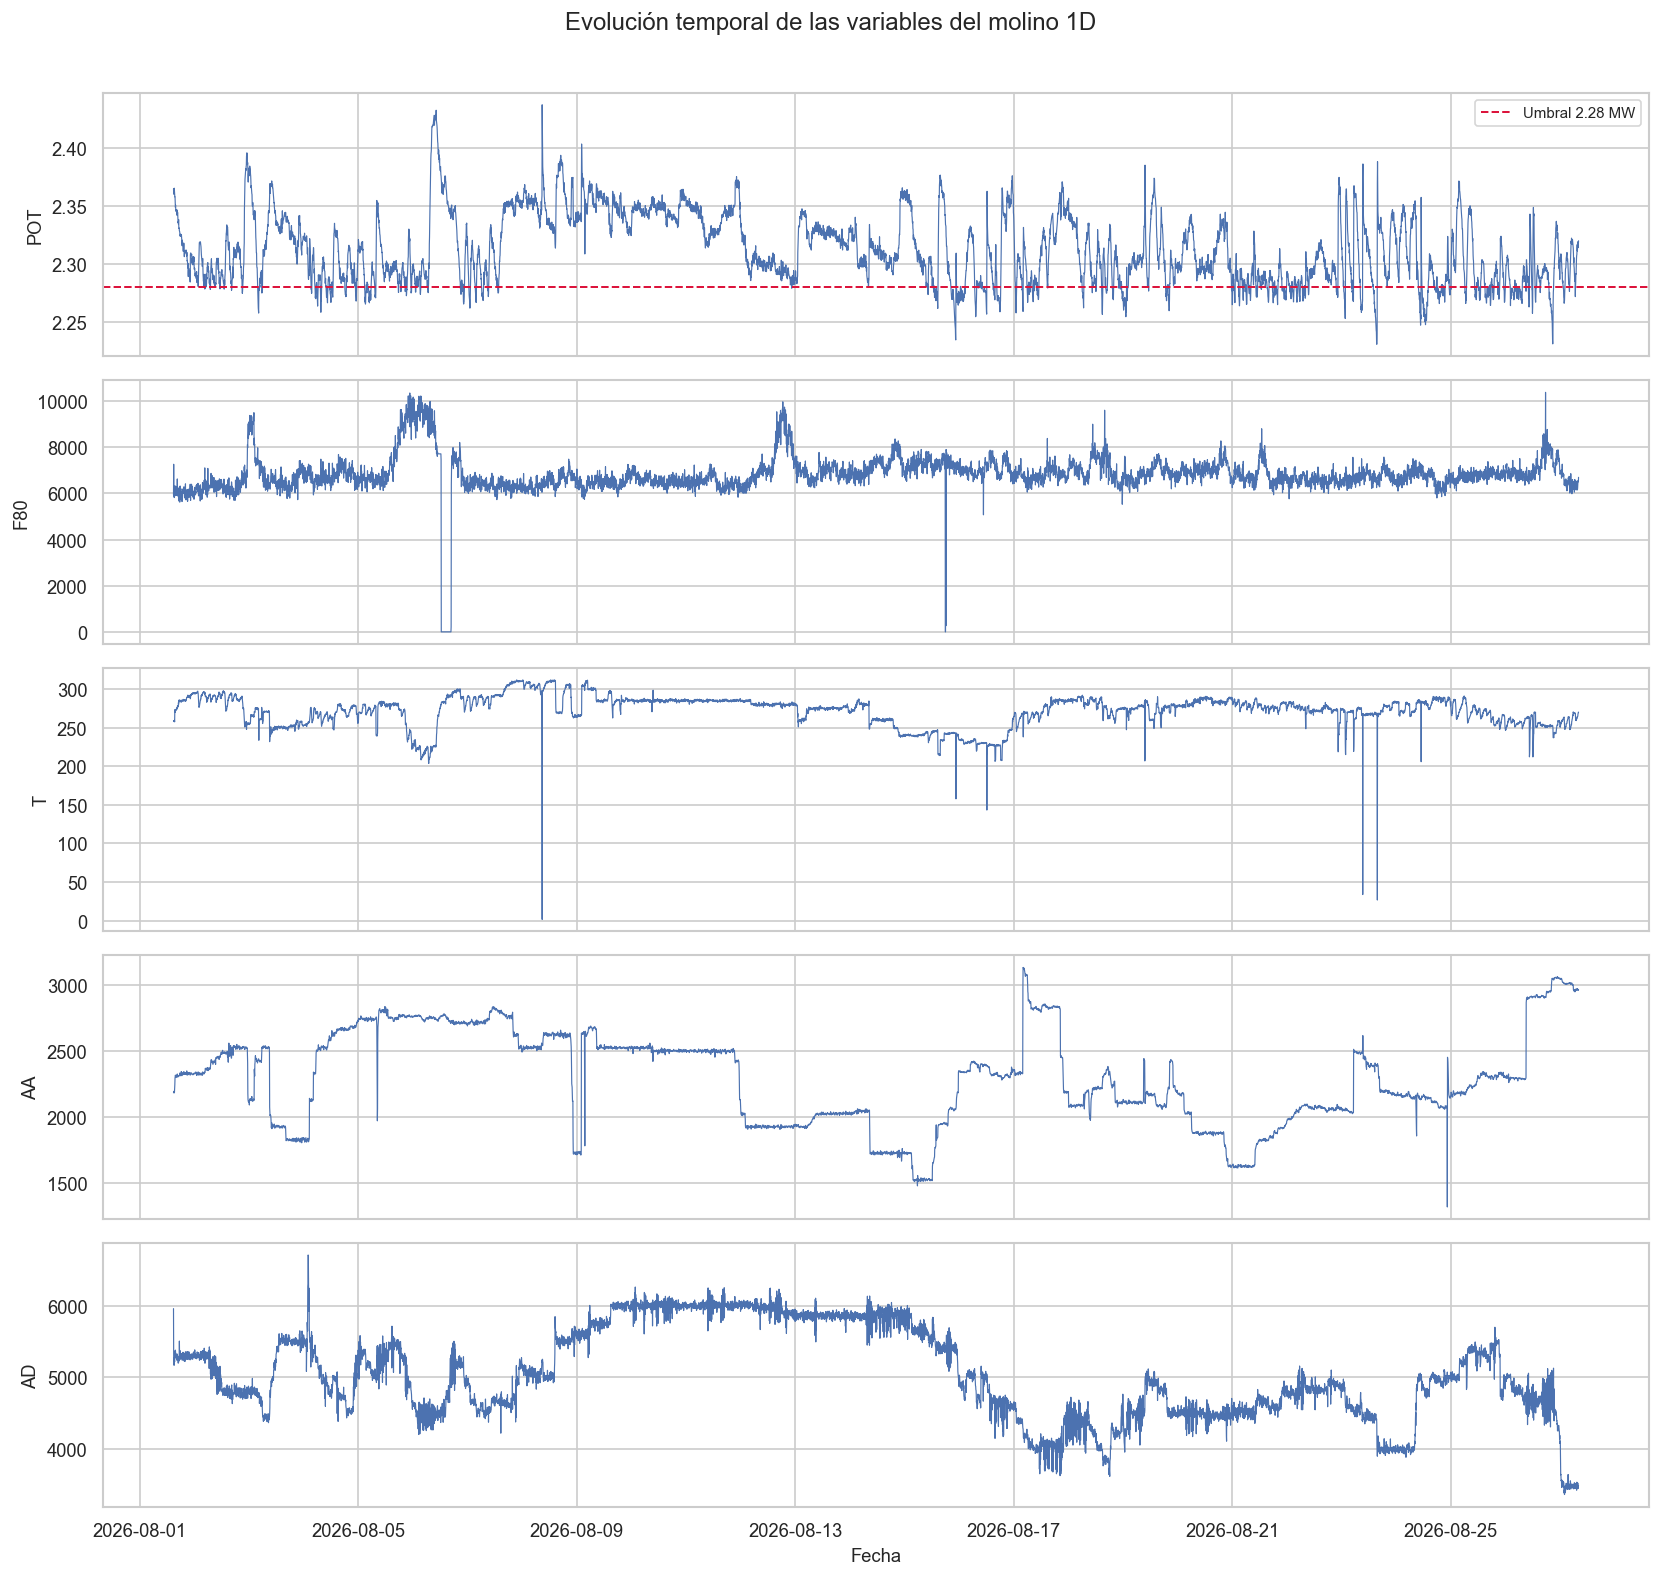

Figura guardada: resultados_tft_15min_final_prueba3\figuras\02_correlacion_pearson.png


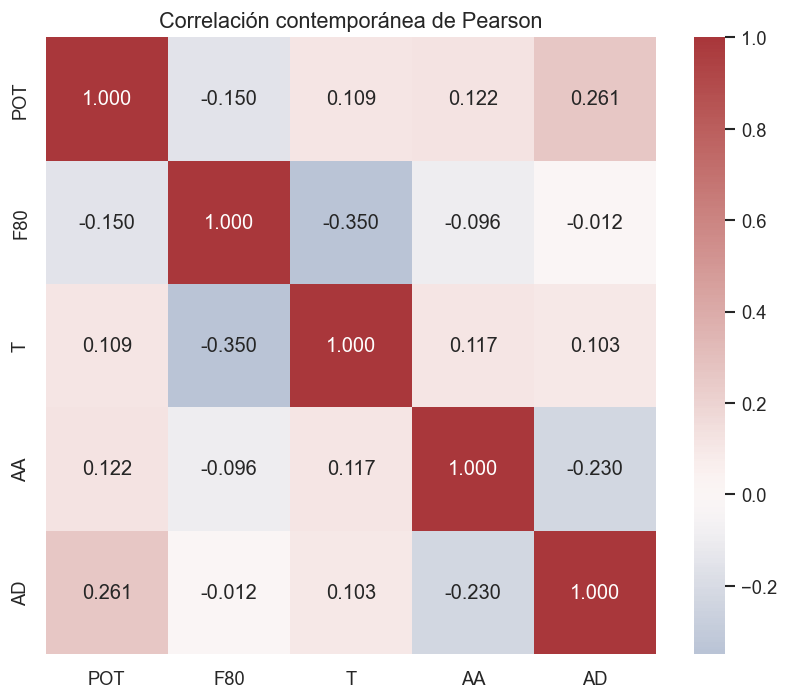

Figura guardada: resultados_tft_15min_final_prueba3\figuras\03_autocorrelacion_pot.png


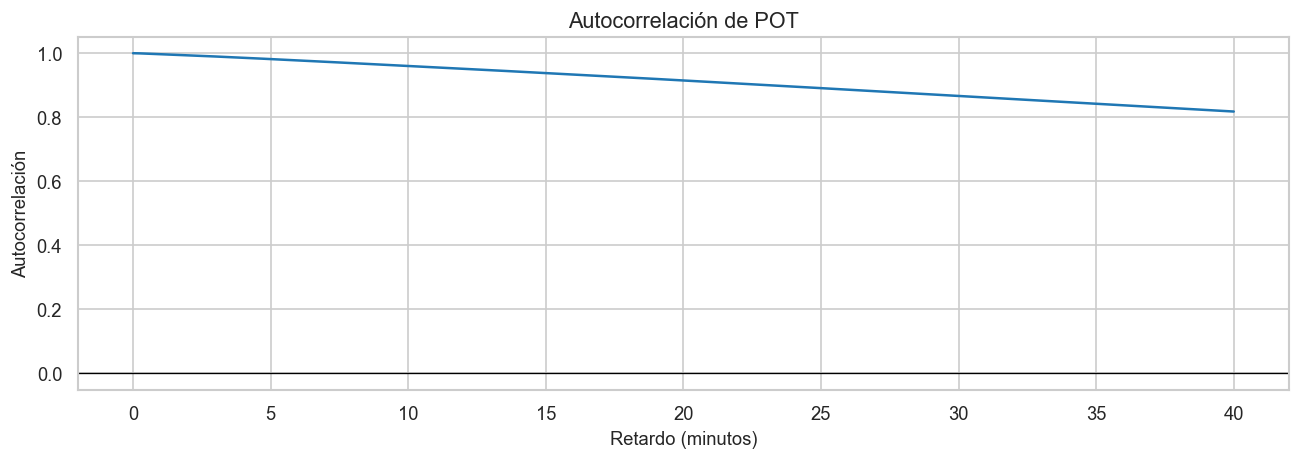

In [9]:
# ============================================================
# 9. FIGURAS EXPLORATORIAS
# ============================================================

plot_df = df_15s.iloc[::20]

fig, axes = plt.subplots(5, 1, figsize=(14, 13), sharex=True)
for axis, column in zip(axes, [TARGET] + PAST_COVARS):
    axis.plot(plot_df.index, plot_df[column], linewidth=0.7)
    axis.set_ylabel(column)
axes[0].axhline(
    POWER_DANGER_THRESHOLD,
    color="crimson",
    linestyle="--",
    linewidth=1.2,
    label=f"Umbral {POWER_DANGER_THRESHOLD:.2f} MW",
)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Fecha")
fig.suptitle("Evolución temporal de las variables del molino 1D", y=1.01)
save_figure("01_series_temporales.png")
plt.show()

correlation = df_15s[[TARGET] + PAST_COVARS].corr(method="pearson")
plt.figure(figsize=(7, 6))
sns.heatmap(correlation, annot=True, fmt=".3f", cmap="vlag", center=0)
plt.title("Correlación contemporánea de Pearson")
save_figure("02_correlacion_pearson.png")
plt.show()

max_lag = 160  # 40 minutos a 15 s
acf_values = acf(df_15s[TARGET].values, nlags=max_lag, fft=True)
lag_minutes = np.arange(max_lag + 1) * pd.Timedelta(MODEL_FREQ).total_seconds() / 60
plt.figure(figsize=(11, 4))
plt.plot(lag_minutes, acf_values, color="#1f77b4")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Retardo (minutos)")
plt.ylabel("Autocorrelación")
plt.title("Autocorrelación de POT")
save_figure("03_autocorrelacion_pot.png")
plt.show()


## 5. División cronológica y prevención de fuga

La división se realiza por posición temporal, sin barajado. Los escaladores se ajustan exclusivamente con entrenamiento. Para la pérdida de validación y el rolling origin se incorporan 120 observaciones anteriores únicamente como contexto; esas observaciones no se contabilizan como resultados del bloque siguiente.


In [10]:
# ============================================================
# 10. DIVISIÓN TRAIN / VALIDATION / TEST Y COBERTURA DINÁMICA
# ============================================================

steps_per_day = int(pd.Timedelta(days=1) / pd.Timedelta(MODEL_FREQ))
val_len = VAL_DAYS * steps_per_day
test_len = TEST_DAYS * steps_per_day
total_len = len(df_15s)
train_len = total_len - val_len - test_len

if train_len <= INPUT_CHUNK_LENGTH + OUTPUT_CHUNK_LENGTH:
    raise ValueError("No existe información suficiente para entrenar el TFT.")
if val_len < OUTPUT_CHUNK_LENGTH or test_len < OUTPUT_CHUNK_LENGTH:
    raise ValueError("Validación o prueba es menor que el horizonte configurado.")

train_start_idx = 0
val_start_idx = train_len
test_start_idx = train_len + val_len

split_table = pd.DataFrame([
    {"conjunto": "Entrenamiento", "inicio": df_15s.index[train_start_idx], "fin": df_15s.index[val_start_idx - 1], "registros": train_len, "proporcion": train_len / total_len},
    {"conjunto": "Validación", "inicio": df_15s.index[val_start_idx], "fin": df_15s.index[test_start_idx - 1], "registros": val_len, "proporcion": val_len / total_len},
    {"conjunto": "Prueba", "inicio": df_15s.index[test_start_idx], "fin": df_15s.index[-1], "registros": test_len, "proporcion": test_len / total_len},
])
display(split_table)
split_table.to_csv(TABLE_DIR / "division_cronologica.csv", index=False)

def numero_esperado_pronosticos(block_length):
    if block_length < OUTPUT_CHUNK_LENGTH:
        return 0
    return ((block_length - OUTPUT_CHUNK_LENGTH) // ROLLING_STRIDE) + 1

expected_val_forecasts = numero_esperado_pronosticos(val_len)
expected_test_forecasts = numero_esperado_pronosticos(test_len)
expected_val_rows = expected_val_forecasts * OUTPUT_CHUNK_LENGTH
expected_test_rows = expected_test_forecasts * OUTPUT_CHUNK_LENGTH

assert expected_val_forecasts > 0 and expected_test_forecasts > 0
assert train_len + val_len + test_len == total_len

origin_summary = pd.DataFrame([
    {"particion": "validation", "origenes": expected_val_forecasts, "pasos_por_trayectoria": OUTPUT_CHUNK_LENGTH, "puntos_evaluados": expected_val_rows, "cobertura_particion_pct": 100 * expected_val_rows / val_len},
    {"particion": "test", "origenes": expected_test_forecasts, "pasos_por_trayectoria": OUTPUT_CHUNK_LENGTH, "puntos_evaluados": expected_test_rows, "cobertura_particion_pct": 100 * expected_test_rows / test_len},
])
display(origin_summary)
origin_summary.to_csv(TABLE_DIR / "resumen_origenes_tft.csv", index=False)


,conjunto,inicio,fin,registros,proporcion
0,Entrenamiento,2026-08-01 14:45:00,2026-08-21 08:13:00,113633,0.766791
1,Validación,2026-08-21 08:13:15,2026-08-24 08:13:00,17280,0.116605
2,Prueba,2026-08-24 08:13:15,2026-08-27 08:13:00,17280,0.116605


,particion,origenes,pasos_por_trayectoria,puntos_evaluados,cobertura_particion_pct
0,validation,288,60,17280,100.000000
1,test,288,60,17280,100.000000


## 6. Construcción de series y escalamiento

`POT` y las covariables se normalizan con escaladores separados. Cada escalador se ajusta únicamente sobre el bloque de entrenamiento y luego se aplica, sin reajuste, al periodo completo.


In [11]:
# ============================================================
# 11. IMPORTACIONES DE DARTS Y LIGHTNING
# ============================================================

import darts
import torch
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import TFTModel
from darts.utils.likelihood_models import QuantileRegression
from sklearn.preprocessing import StandardScaler

try:
    from lightning.pytorch import seed_everything
    from lightning.pytorch.callbacks import EarlyStopping
    from lightning.pytorch.loggers import CSVLogger
    lightning_package = "lightning"
except ImportError:
    from pytorch_lightning import seed_everything
    from pytorch_lightning.callbacks import EarlyStopping
    from pytorch_lightning.loggers import CSVLogger
    lightning_package = "pytorch_lightning"

seed_everything(SEED, workers=True)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Python:", sys.version.split()[0])
print("Darts:", darts.__version__)
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
if darts.__version__ != "0.31.0":
    warnings.warn(
        f"El protocolo fue validado para Darts 0.31.0 y se detectó {darts.__version__}."
    )


C:\Users\jgomeze\Entorno\tf-gpu-packed\lib\site-packages\holidays\__init__.py:32: FutureIncompatibilityWarning: 

This is a future version incompatibility warning from Holidays library v0.58
to inform you about an upcoming change in our API versioning strategy that may affect your
project's dependencies. Starting from version 1.0 onwards, we will be following a loose form of
Semantic Versioning (SemVer, https://semver.org) to provide clearer communication regarding any
potential breaking changes.

This means that while we strive to maintain backward compatibility, there might be occasional
updates that introduce breaking changes to our API. To ensure the stability of your projects,
we highly recommend pinning the version of our API that you rely on. You can pin your current
holidays v0.x dependency (e.g., holidays==0.58) or limit it (e.g., holidays<1.0) in order to
avoid potentially unwanted upgrade to the version 1.0 when it's released (ETA 2024Q4 - 2025Q1).

If you have any questions

Python: 3.8.20
Darts: 0.31.0
PyTorch: 2.4.1+cu121
CUDA disponible: True
GPU: Quadro RTX 5000


In [12]:
# ============================================================
# 12. TIMESERIES Y SCALERS AJUSTADOS SOLO CON TRAIN
# ============================================================

model_df = df_15s.reset_index()

series_y_raw = TimeSeries.from_dataframe(
    model_df,
    time_col=DATE_COL,
    value_cols=[TARGET],
    fill_missing_dates=False,
    freq=MODEL_FREQ,
)

series_past_raw = TimeSeries.from_dataframe(
    model_df,
    time_col=DATE_COL,
    value_cols=PAST_COVARS,
    fill_missing_dates=False,
    freq=MODEL_FREQ,
)

y_train_raw = series_y_raw[:train_len]
past_train_raw = series_past_raw[:train_len]

scaler_y = Scaler(StandardScaler())
scaler_past = Scaler(StandardScaler())

scaler_y.fit(y_train_raw)
scaler_past.fit(past_train_raw)

series_y_scaled = scaler_y.transform(series_y_raw)
series_past_scaled = scaler_past.transform(series_past_raw)

y_train_scaled = series_y_scaled[:train_len]
past_train_scaled = series_past_scaled[:train_len]

# Exactamente 120 puntos previos de train + todas las etiquetas de validación.
y_val_fit_scaled = series_y_scaled[
    val_start_idx - INPUT_CHUNK_LENGTH:test_start_idx
]
past_val_fit_scaled = series_past_scaled[
    val_start_idx - INPUT_CHUNK_LENGTH:test_start_idx
]

assert len(y_val_fit_scaled) == INPUT_CHUNK_LENGTH + val_len
assert len(past_val_fit_scaled) == INPUT_CHUNK_LENGTH + val_len

print("Train target:", len(y_train_scaled))
print("Validación para early stopping, incluida la ventana de contexto:", len(y_val_fit_scaled))


Train target: 113633
Validación para early stopping, incluida la ventana de contexto: 17400


## 7. Configuración y entrenamiento del TFT

La arquitectura produce `OUTPUT_CHUNK_LENGTH` pasos en una única salida, evitando recursión. `add_relative_index=True` proporciona al decodificador una posición temporal conocida sin utilizar covariables operativas futuras. La función objetivo es la pérdida por cuantiles para P10, P50 y P90.


In [13]:
# ============================================================
# 13. CALLBACKS, DISPOSITIVO Y MODELO
# ============================================================

use_gpu = torch.cuda.is_available()
accelerator = "gpu" if use_gpu else "cpu"
precision = "64-true" if use_gpu else "64-true"

early_stopper = EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
    mode="min",
    verbose=True,
)

csv_logger = CSVLogger(
    save_dir=str(ARTIFACT_DIR),
    name="historial_entrenamiento",
)

likelihood = QuantileRegression(quantiles=QUANTILES)

trainer_kwargs = {
    "accelerator": accelerator,
    "devices": 1,
    "precision": precision,
    "callbacks": [early_stopper],
    "logger": csv_logger,
    "gradient_clip_val": 0.5,
    "enable_progress_bar": True,
    "enable_model_summary": True,
    "deterministic": False,
}

model = TFTModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    hidden_size=HIDDEN_SIZE,
    hidden_continuous_size=HIDDEN_CONTINUOUS_SIZE,
    lstm_layers=LSTM_LAYERS,
    num_attention_heads=ATTENTION_HEADS,
    dropout=DROPOUT,
    add_relative_index=True,
    likelihood=likelihood,
    batch_size=BATCH_SIZE,
    n_epochs=MAX_EPOCHS,
    optimizer_kwargs={
        "lr": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
    },
    random_state=SEED,
    model_name=MODEL_NAME,
    work_dir=str(MODEL_DIR),
    save_checkpoints=True,
    force_reset=True,
    nr_epochs_val_period=1,
    log_tensorboard=False,
    pl_trainer_kwargs=trainer_kwargs,
)

model_configuration = {
    "input_chunk_length": INPUT_CHUNK_LENGTH,
    "output_chunk_length": OUTPUT_CHUNK_LENGTH,
    "input_minutes": INPUT_MINUTES,
    "horizon_minutes": HORIZON_MINUTES,
    "rolling_stride": ROLLING_STRIDE,
    "rolling_stride_minutes": ROLLING_STRIDE_MINUTES,
    "hidden_size": HIDDEN_SIZE,
    "hidden_continuous_size": HIDDEN_CONTINUOUS_SIZE,
    "lstm_layers": LSTM_LAYERS,
    "attention_heads": ATTENTION_HEADS,
    "dropout": DROPOUT,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "quantiles": QUANTILES,
    "seed": SEED,
    "accelerator": accelerator,
    "precision": precision,
}
save_json(model_configuration, MODEL_DIR / "configuracion_tft.json")
display(pd.DataFrame([model_configuration]).T.rename(columns={0: "valor"}))


,valor
input_chunk_length,120
output_chunk_length,60
input_minutes,30.000000
horizon_minutes,15.000000
rolling_stride,60
rolling_stride_minutes,15.000000
hidden_size,32
hidden_continuous_size,16
lstm_layers,1
attention_heads,2


In [14]:
# ============================================================
# 14. ENTRENAMIENTO
# ============================================================

training_start = time.time()

model.fit(
    series=y_train_scaled,
    past_covariates=past_train_scaled,
    val_series=y_val_fit_scaled,
    val_past_covariates=past_val_fit_scaled,
    verbose=True,
    dataloader_kwargs={
        "num_workers": 0,
        "pin_memory": use_gpu,
    },
)

training_seconds = time.time() - training_start
print(f"Tiempo de entrenamiento: {training_seconds / 60:.2f} minutos")

try:
    best_model = TFTModel.load_from_checkpoint(
        model_name=MODEL_NAME,
        work_dir=str(MODEL_DIR),
        best=True,
    )
    print("Mejor checkpoint cargado correctamente.")
except Exception as checkpoint_error:
    warnings.warn(
        f"No se pudo cargar el mejor checkpoint; se utilizará el estado final. Detalle: {checkpoint_error}"
    )
    best_model = model

best_model.save(str(MODEL_DIR / "tft_modelo_final.pt"))


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 11.9 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 1.8 K  | train
6  | static_context_grn                | _GatedResidualNetwork            | 4.3 K  | train
7  | static_cont

Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Metric val_loss improved. New best score: 0.226


...

Metric val_loss improved by 0.002 >= min_delta = 0.0001. New best score: 0.175


Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Columnas de pérdida: ['train_loss', 'val_loss']


,epoch,train_loss,val_loss
27,27,0.128660,0.172761
28,28,0.128593,0.176054
29,29,0.131480,0.173341
30,30,0.127880,0.172815
31,31,0.128758,0.177600


Figura guardada: resultados_tft_15min_final_prueba3\figuras\04_curvas_entrenamiento.png


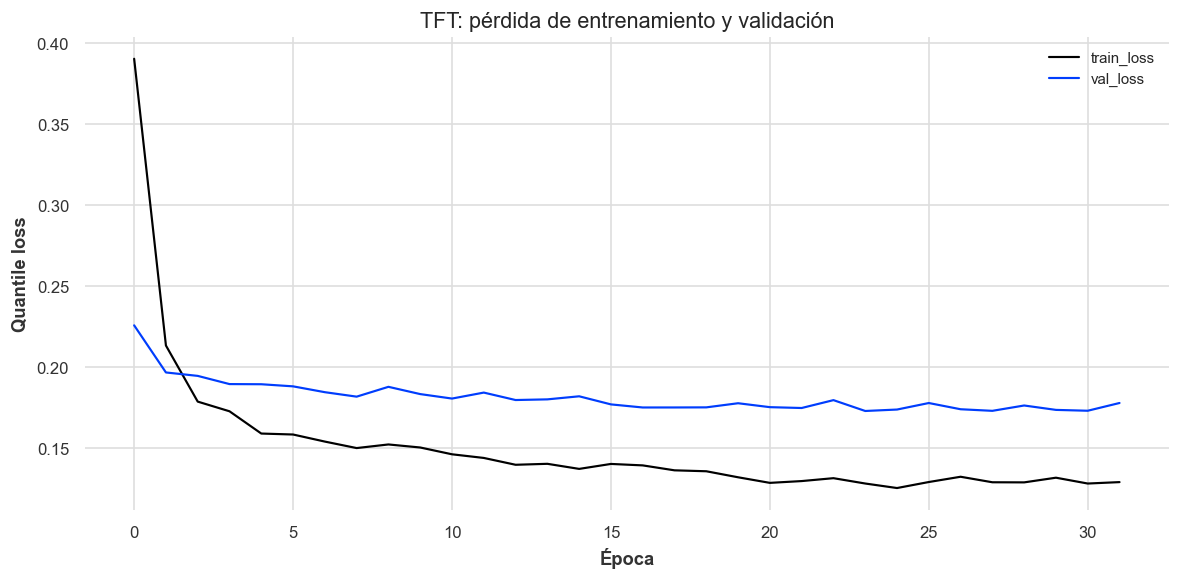

In [15]:
# ============================================================
# 15. CURVAS DE ENTRENAMIENTO
# ============================================================

metrics_path = Path(csv_logger.log_dir) / "metrics.csv"
training_history = pd.DataFrame()

if metrics_path.exists():
    history_raw = pd.read_csv(metrics_path)
    loss_columns = [
        column for column in history_raw.columns
        if "loss" in column.lower()
    ]
    print("Columnas de pérdida:", loss_columns)

    if "epoch" in history_raw.columns and loss_columns:
        training_history = (
            history_raw[["epoch"] + loss_columns]
            .groupby("epoch", as_index=False)
            .mean(numeric_only=True)
        )
        display(training_history.tail())
        training_history.to_csv(
            TABLE_DIR / "historial_entrenamiento_tft.csv",
            index=False,
        )

        plt.figure(figsize=(10, 5))
        for column in loss_columns:
            if column in training_history and training_history[column].notna().any():
                plt.plot(training_history["epoch"], training_history[column], label=column)
        plt.xlabel("Época")
        plt.ylabel("Quantile loss")
        plt.title("TFT: pérdida de entrenamiento y validación")
        plt.legend()
        save_figure("04_curvas_entrenamiento.png")
        plt.show()
else:
    warnings.warn(f"No se encontró el historial en {metrics_path}")


## 8. Evaluación *rolling origin* estricta

Validación y prueba se evalúan por separado. Cada serie contiene `INPUT_CHUNK_LENGTH` puntos previos de contexto y su propio bloque cronológico. El número de pronósticos y la cobertura efectiva se calculan desde `OUTPUT_CHUNK_LENGTH` y `ROLLING_STRIDE`; ninguna predicción de validación puede alcanzar el periodo de prueba.


In [16]:
# ============================================================
# 16. MÉTRICAS DETERMINÍSTICAS Y PROBABILÍSTICAS
# ============================================================

def deterministic_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    error = y_true - y_pred
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    nonzero = np.abs(y_true) > 1e-12
    mape = 100 * np.mean(np.abs(error[nonzero] / y_true[nonzero]))
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "MAPE": float(mape),
        "R2": float(r2),
    }


def pinball_loss(y_true, y_quantile, quantile):
    error = np.asarray(y_true) - np.asarray(y_quantile)
    return float(np.mean(np.maximum(quantile * error, (quantile - 1) * error)))


def probabilistic_metrics(frame):
    lower = frame["y_pred_p10"].to_numpy()
    median = frame["y_pred_p50"].to_numpy()
    upper = frame["y_pred_p90"].to_numpy()
    actual = frame["y_true"].to_numpy()
    crossing = (lower > median) | (median > upper)
    return {
        "COVERAGE_P10_P90": float(np.mean((actual >= lower) & (actual <= upper))),
        "MEAN_INTERVAL_WIDTH": float(np.mean(upper - lower)),
        "PINBALL_P10": pinball_loss(actual, lower, 0.10),
        "PINBALL_P50": pinball_loss(actual, median, 0.50),
        "PINBALL_P90": pinball_loss(actual, upper, 0.90),
        "QUANTILE_CROSSING_RATE": float(np.mean(crossing)),
    }


def event_metrics(y_true, y_score, threshold=POWER_DANGER_THRESHOLD):
    real = np.asarray(y_true) < threshold
    predicted = np.asarray(y_score) < threshold
    tp = int(np.sum(real & predicted))
    fp = int(np.sum(~real & predicted))
    fn = int(np.sum(real & ~predicted))
    tn = int(np.sum(~real & ~predicted))
    precision_event = tp / (tp + fp) if tp + fp else np.nan
    recall_event = tp / (tp + fn) if tp + fn else np.nan
    specificity = tn / (tn + fp) if tn + fp else np.nan
    f1 = (
        2 * precision_event * recall_event / (precision_event + recall_event)
        if np.isfinite(precision_event)
        and np.isfinite(recall_event)
        and precision_event + recall_event > 0
        else np.nan
    )
    balanced_accuracy = (
        np.nanmean([recall_event, specificity])
        if np.isfinite(recall_event) or np.isfinite(specificity)
        else np.nan
    )
    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "PRECISION": precision_event,
        "RECALL": recall_event,
        "SPECIFICITY": specificity,
        "F1": f1,
        "BALANCED_ACCURACY": balanced_accuracy,
        "REAL_EVENTS": int(real.sum()),
        "PREDICTED_EVENTS": int(predicted.sum()),
    }


In [17]:
# ============================================================
# 17. FUNCIONES DE PRONÓSTICO Y CONVERSIÓN DINÁMICAS
# ============================================================

def coerce_forecast_list(forecasts):
    return forecasts if isinstance(forecasts, list) else [forecasts]

def generate_historical_forecasts(
    fitted_model,
    eval_series_scaled,
    eval_past_scaled,
    dataset_start_time,
    dataset_name,
):
    block_length = len(eval_series_scaled) - INPUT_CHUNK_LENGTH
    expected_forecasts = numero_esperado_pronosticos(block_length)
    if expected_forecasts <= 0:
        raise ValueError(f"{dataset_name}: el bloque es menor que el horizonte.")

    print(
        f"{dataset_name}: generando {expected_forecasts} pronósticos "
        f"de {OUTPUT_CHUNK_LENGTH} pasos ({HORIZON_MINUTES:g} min)..."
    )

    try:
        forecasts = fitted_model.historical_forecasts(
            series=eval_series_scaled,
            past_covariates=eval_past_scaled,
            start=dataset_start_time,
            forecast_horizon=OUTPUT_CHUNK_LENGTH,
            stride=ROLLING_STRIDE,
            retrain=False,
            overlap_end=False,
            last_points_only=False,
            num_samples=NUM_SAMPLES_EVAL,
            verbose=True,
            show_warnings=True,
            enable_optimization=True,
        )
        forecasts = coerce_forecast_list(forecasts)
    except Exception as optimized_error:
        warnings.warn(
            "La ruta optimizada falló; se utilizará la ruta secuencial, "
            f"más lenta. Detalle: {optimized_error}"
        )
        forecasts = []
        for origin_position in range(
            INPUT_CHUNK_LENGTH,
            len(eval_series_scaled) - OUTPUT_CHUNK_LENGTH + 1,
            ROLLING_STRIDE,
        ):
            context_y = eval_series_scaled[:origin_position]
            context_past = eval_past_scaled[:origin_position]
            forecast = fitted_model.predict(
                n=OUTPUT_CHUNK_LENGTH,
                series=context_y,
                past_covariates=context_past,
                num_samples=NUM_SAMPLES_EVAL,
                verbose=False,
            )
            forecasts.append(forecast)

    if len(forecasts) != expected_forecasts:
        raise ValueError(
            f"{dataset_name}: se esperaban {expected_forecasts} pronósticos "
            f"y se generaron {len(forecasts)}."
        )
    if forecasts[0].start_time() != dataset_start_time:
        raise ValueError(
            f"{dataset_name}: el primer pronóstico inicia en "
            f"{forecasts[0].start_time()} y debía iniciar en {dataset_start_time}."
        )
    return forecasts

def forecasts_to_frame(forecasts, eval_series_raw, dataset_name):
    actual = eval_series_raw.pd_dataframe().copy()
    actual.columns = ["y_true"]
    rows = []

    for forecast_id, forecast_scaled in enumerate(forecasts):
        p10 = scaler_y.inverse_transform(forecast_scaled.quantile_timeseries(0.10)).pd_dataframe()
        p50 = scaler_y.inverse_transform(forecast_scaled.quantile_timeseries(0.50)).pd_dataframe()
        p90 = scaler_y.inverse_transform(forecast_scaled.quantile_timeseries(0.90)).pd_dataframe()
        forecast_index = p50.index
        last_observation_time = forecast_index[0] - pd.Timedelta(MODEL_FREQ)
        if last_observation_time not in actual.index:
            raise ValueError(f"No se encontró el origen de persistencia: {last_observation_time}")
        persistence_value = float(actual.loc[last_observation_time, "y_true"])
        lead_steps = np.arange(1, len(forecast_index) + 1)

        block = pd.DataFrame({
            "dataset": dataset_name,
            "forecast_id": forecast_id,
            "forecast_start": forecast_index[0],
            "timestamp": forecast_index,
            "lead_step": lead_steps,
            "lead_min": lead_steps * MODEL_STEP_SECONDS / 60.0,
            "y_pred_p10": p10.iloc[:, 0].to_numpy(),
            "y_pred_p50": p50.iloc[:, 0].to_numpy(),
            "y_pred_p90": p90.iloc[:, 0].to_numpy(),
            "y_persistencia": persistence_value,
        }).set_index("timestamp")
        block = block.join(actual, how="left")
        rows.append(block)

    frame = pd.concat(rows).sort_index()
    if frame.index.duplicated().any():
        raise ValueError(f"{dataset_name}: existen timestamps pronosticados duplicados.")
    if frame["y_true"].isna().any():
        raise ValueError(f"{dataset_name}: faltan observaciones reales para evaluar.")
    return frame

def evaluate_period(fitted_model, context_start_idx, dataset_start_idx, dataset_end_idx, dataset_name):
    eval_y_scaled = series_y_scaled[context_start_idx:dataset_end_idx]
    eval_past_scaled = series_past_scaled[context_start_idx:dataset_end_idx]
    eval_y_raw = series_y_raw[context_start_idx:dataset_end_idx]
    dataset_start_time = series_y_raw.time_index[dataset_start_idx]

    if dataset_start_idx - context_start_idx != INPUT_CHUNK_LENGTH:
        raise ValueError(
            f"La ventana de contexto debe contener {INPUT_CHUNK_LENGTH} pasos."
        )

    forecasts = generate_historical_forecasts(
        fitted_model, eval_y_scaled, eval_past_scaled, dataset_start_time, dataset_name
    )
    frame = forecasts_to_frame(forecasts, eval_y_raw, dataset_name)

    expected_forecasts = numero_esperado_pronosticos(dataset_end_idx - dataset_start_idx)
    expected_rows = expected_forecasts * OUTPUT_CHUNK_LENGTH
    if len(frame) != expected_rows:
        raise ValueError(
            f"{dataset_name}: se esperaban {expected_rows} predicciones y se obtuvieron {len(frame)}."
        )
    if frame.index.min() != series_y_raw.time_index[dataset_start_idx]:
        raise ValueError(f"{dataset_name}: inicio de evaluación incorrecto.")

    expected_last_position = (
        dataset_start_idx
        + (expected_forecasts - 1) * ROLLING_STRIDE
        + OUTPUT_CHUNK_LENGTH
        - 1
    )
    if frame.index.max() != series_y_raw.time_index[expected_last_position]:
        raise ValueError(f"{dataset_name}: fin efectivo de evaluación incorrecto.")
    return frame


In [18]:
# ============================================================
# 18. EVALUAR VALIDACIÓN Y PRUEBA POR SEPARADO
# ============================================================

evaluation_start = time.time()

eval_validation = evaluate_period(
    fitted_model=best_model,
    context_start_idx=val_start_idx - INPUT_CHUNK_LENGTH,
    dataset_start_idx=val_start_idx,
    dataset_end_idx=test_start_idx,
    dataset_name="VALIDATION",
)

# La siguiente aserción impide que validación invada prueba.
assert eval_validation.index.max() < series_y_raw.time_index[test_start_idx]

eval_test = evaluate_period(
    fitted_model=best_model,
    context_start_idx=test_start_idx - INPUT_CHUNK_LENGTH,
    dataset_start_idx=test_start_idx,
    dataset_end_idx=total_len,
    dataset_name="TEST",
)

assert len(eval_validation) == expected_val_rows
assert len(eval_test) == expected_test_rows
assert eval_validation["forecast_id"].nunique() == expected_val_forecasts
assert eval_test["forecast_id"].nunique() == expected_test_forecasts

evaluation_seconds = time.time() - evaluation_start
print(f"Evaluación completada en {evaluation_seconds / 60:.2f} minutos")

eval_validation.to_csv(TABLE_DIR / "predicciones_validacion_tft.csv")
eval_test.to_csv(TABLE_DIR / "predicciones_prueba_tft.csv")


VALIDATION: generando 288 pronósticos de 60 pasos (15 min)...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

TEST: generando 288 pronósticos de 60 pasos (15 min)...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

Evaluación completada en 1.65 minutos


## 9. Métricas determinísticas y probabilísticas

Las métricas globales aplanan todas las trayectorias producidas por la configuración. También se calculan por `lead_step`, lo que permite identificar desde qué horizonte el TFT aporta valor frente a persistencia. La cantidad de trayectorias y pasos se toma de los objetos evaluados, no de constantes escritas manualmente.


In [19]:
# ============================================================
# 19. MÉTRICAS GLOBALES
# ============================================================

global_rows = []
probability_rows = []

for dataset_name, frame in [
    ("VALIDATION", eval_validation),
    ("TEST", eval_test),
]:
    global_rows.append({
        "dataset": dataset_name,
        "modelo": "TFT_P50",
        **deterministic_metrics(frame["y_true"], frame["y_pred_p50"]),
    })
    global_rows.append({
        "dataset": dataset_name,
        "modelo": "PERSISTENCIA",
        **deterministic_metrics(frame["y_true"], frame["y_persistencia"]),
    })
    probability_rows.append({
        "dataset": dataset_name,
        "modelo": "TFT",
        **probabilistic_metrics(frame),
    })

global_metrics = pd.DataFrame(global_rows)
probability_metrics_table = pd.DataFrame(probability_rows)

display(global_metrics)
display(probability_metrics_table)

global_metrics.to_csv(TABLE_DIR / "metricas_globales_tft.csv", index=False)
probability_metrics_table.to_csv(
    TABLE_DIR / "metricas_probabilisticas_tft.csv",
    index=False,
)


,dataset,modelo,MAE,RMSE,MAPE,R2
0,VALIDATION,TFT_P50,0.004910,0.009781,0.212547,0.861217
1,VALIDATION,PERSISTENCIA,0.004935,0.010557,0.213299,0.838342
2,TEST,TFT_P50,0.004628,0.007281,0.201784,0.902561
3,TEST,PERSISTENCIA,0.004978,0.007862,0.216878,0.886402


,dataset,modelo,COVERAGE_P10_P90,MEAN_INTERVAL_WIDTH,PINBALL_P10,PINBALL_P50,PINBALL_P90,QUANTILE_CROSSING_RATE
0,VALIDATION,TFT,0.802431,0.013191,0.001080,0.002455,0.001585,0.000000
1,TEST,TFT,0.809664,0.013700,0.001060,0.002314,0.001250,0.000000


In [20]:
# ============================================================
# 20. MÉTRICAS POR HORIZONTE
# ============================================================

horizon_rows = []

for dataset_name, frame in [
    ("VALIDATION", eval_validation),
    ("TEST", eval_test),
]:
    for lead_step, subset in frame.groupby("lead_step"):
        tft_metrics = deterministic_metrics(
            subset["y_true"], subset["y_pred_p50"]
        )
        persistence_metrics = deterministic_metrics(
            subset["y_true"], subset["y_persistencia"]
        )
        improvement_mae = (
            100 * (persistence_metrics["MAE"] - tft_metrics["MAE"])
            / persistence_metrics["MAE"]
            if persistence_metrics["MAE"] > 0
            else np.nan
        )
        improvement_rmse = (
            100 * (persistence_metrics["RMSE"] - tft_metrics["RMSE"])
            / persistence_metrics["RMSE"]
            if persistence_metrics["RMSE"] > 0
            else np.nan
        )
        horizon_rows.append({
            "dataset": dataset_name,
            "lead_step": int(lead_step),
            "lead_min": float(subset["lead_min"].iloc[0]),
            "MAE_TFT": tft_metrics["MAE"],
            "RMSE_TFT": tft_metrics["RMSE"],
            "MAPE_TFT": tft_metrics["MAPE"],
            "R2_TFT": tft_metrics["R2"],
            "MAE_PERSISTENCIA": persistence_metrics["MAE"],
            "RMSE_PERSISTENCIA": persistence_metrics["RMSE"],
            "MEJORA_MAE_PCT": improvement_mae,
            "MEJORA_RMSE_PCT": improvement_rmse,
            "GANA_TFT_MAE": tft_metrics["MAE"] < persistence_metrics["MAE"],
        })

metrics_by_horizon = pd.DataFrame(horizon_rows)
display(metrics_by_horizon)
metrics_by_horizon.to_csv(TABLE_DIR / "metricas_por_horizonte_tft.csv", index=False)

final_horizon = metrics_by_horizon[metrics_by_horizon["lead_step"] == OUTPUT_CHUNK_LENGTH]
print(f"Horizonte final de {HORIZON_MINUTES:g} minutos:")
display(final_horizon)
assert len(final_horizon) == 2
assert np.allclose(final_horizon["lead_min"], HORIZON_MINUTES)
final_horizon.to_csv(TABLE_DIR / "metricas_horizonte_final_tft.csv", index=False)


,dataset,lead_step,lead_min,MAE_TFT,RMSE_TFT,MAPE_TFT,R2_TFT,MAE_PERSISTENCIA,RMSE_PERSISTENCIA,MEJORA_MAE_PCT,MEJORA_RMSE_PCT,GANA_TFT_MAE
0,VALIDATION,1,0.250000,0.001603,0.002686,0.069868,0.988976,0.000402,0.000859,-299.017139,-212.679357,False
1,VALIDATION,2,0.500000,0.001714,0.002905,0.074636,0.986996,0.000747,0.001516,-129.427368,-91.544052,False
2,VALIDATION,3,0.750000,0.001887,0.003162,0.082111,0.984643,0.001074,0.002040,-75.662877,-55.042886,False
3,VALIDATION,4,1.000000,0.002059,0.003320,0.089566,0.983149,0.001343,0.002478,-53.344504,-33.984283,False
4,VALIDATION,5,1.250000,0.002210,0.003493,0.096127,0.981389,0.001599,0.002821,-38.275155,-23.813882,False
...,...,...,...,...,...,...,...,...,...,...,...,...
115,TEST,56,14.000000,0.007098,0.010461,0.309253,0.794600,0.007820,0.011092,9.229798,5.688319,True
116,TEST,57,14.250000,0.007185,0.010622,0.313026,0.789860,0.008005,0.011282,10.238362,5.845835,True
117,TEST,58,14.500000,0.007317,0.010786,0.318822,0.784903,0.008167,0.011490,10.405946,6.121340,True
118,TEST,59,14.750000,0.007382,0.010903,0.321650,0.781093,0.008330,0.011745,11.380825,7.168823,True


Horizonte final de 15 minutos:


,dataset,lead_step,lead_min,MAE_TFT,RMSE_TFT,MAPE_TFT,R2_TFT,MAE_PERSISTENCIA,RMSE_PERSISTENCIA,MEJORA_MAE_PCT,MEJORA_RMSE_PCT,GANA_TFT_MAE
59,VALIDATION,60,15.000000,0.006911,0.012070,0.299294,0.780723,0.007636,0.013924,9.497992,13.316236,True
119,TEST,60,15.000000,0.007504,0.011060,0.326929,0.774271,0.008361,0.011904,10.255731,7.084697,True


Figura guardada: resultados_tft_15min_final_prueba3\figuras\05_error_por_horizonte_prueba.png


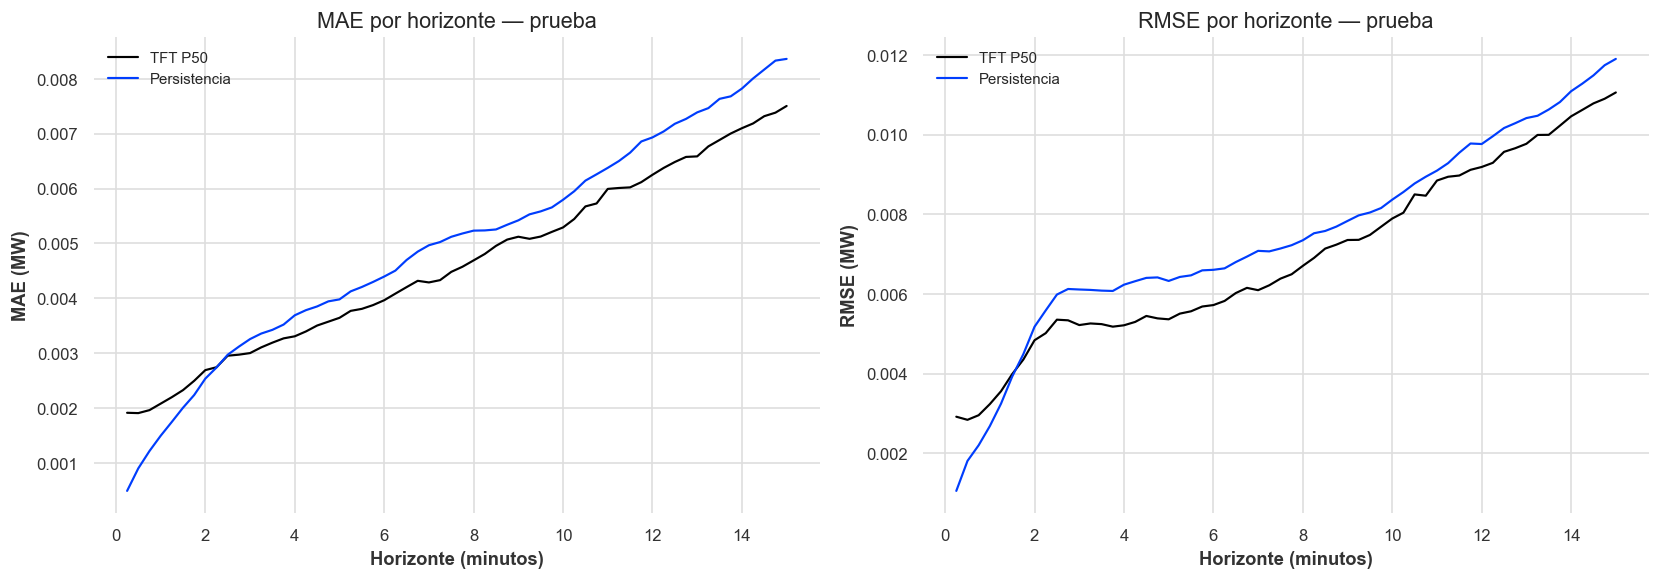

Figura guardada: resultados_tft_15min_final_prueba3\figuras\06_trayectorias_representativas_prueba.png


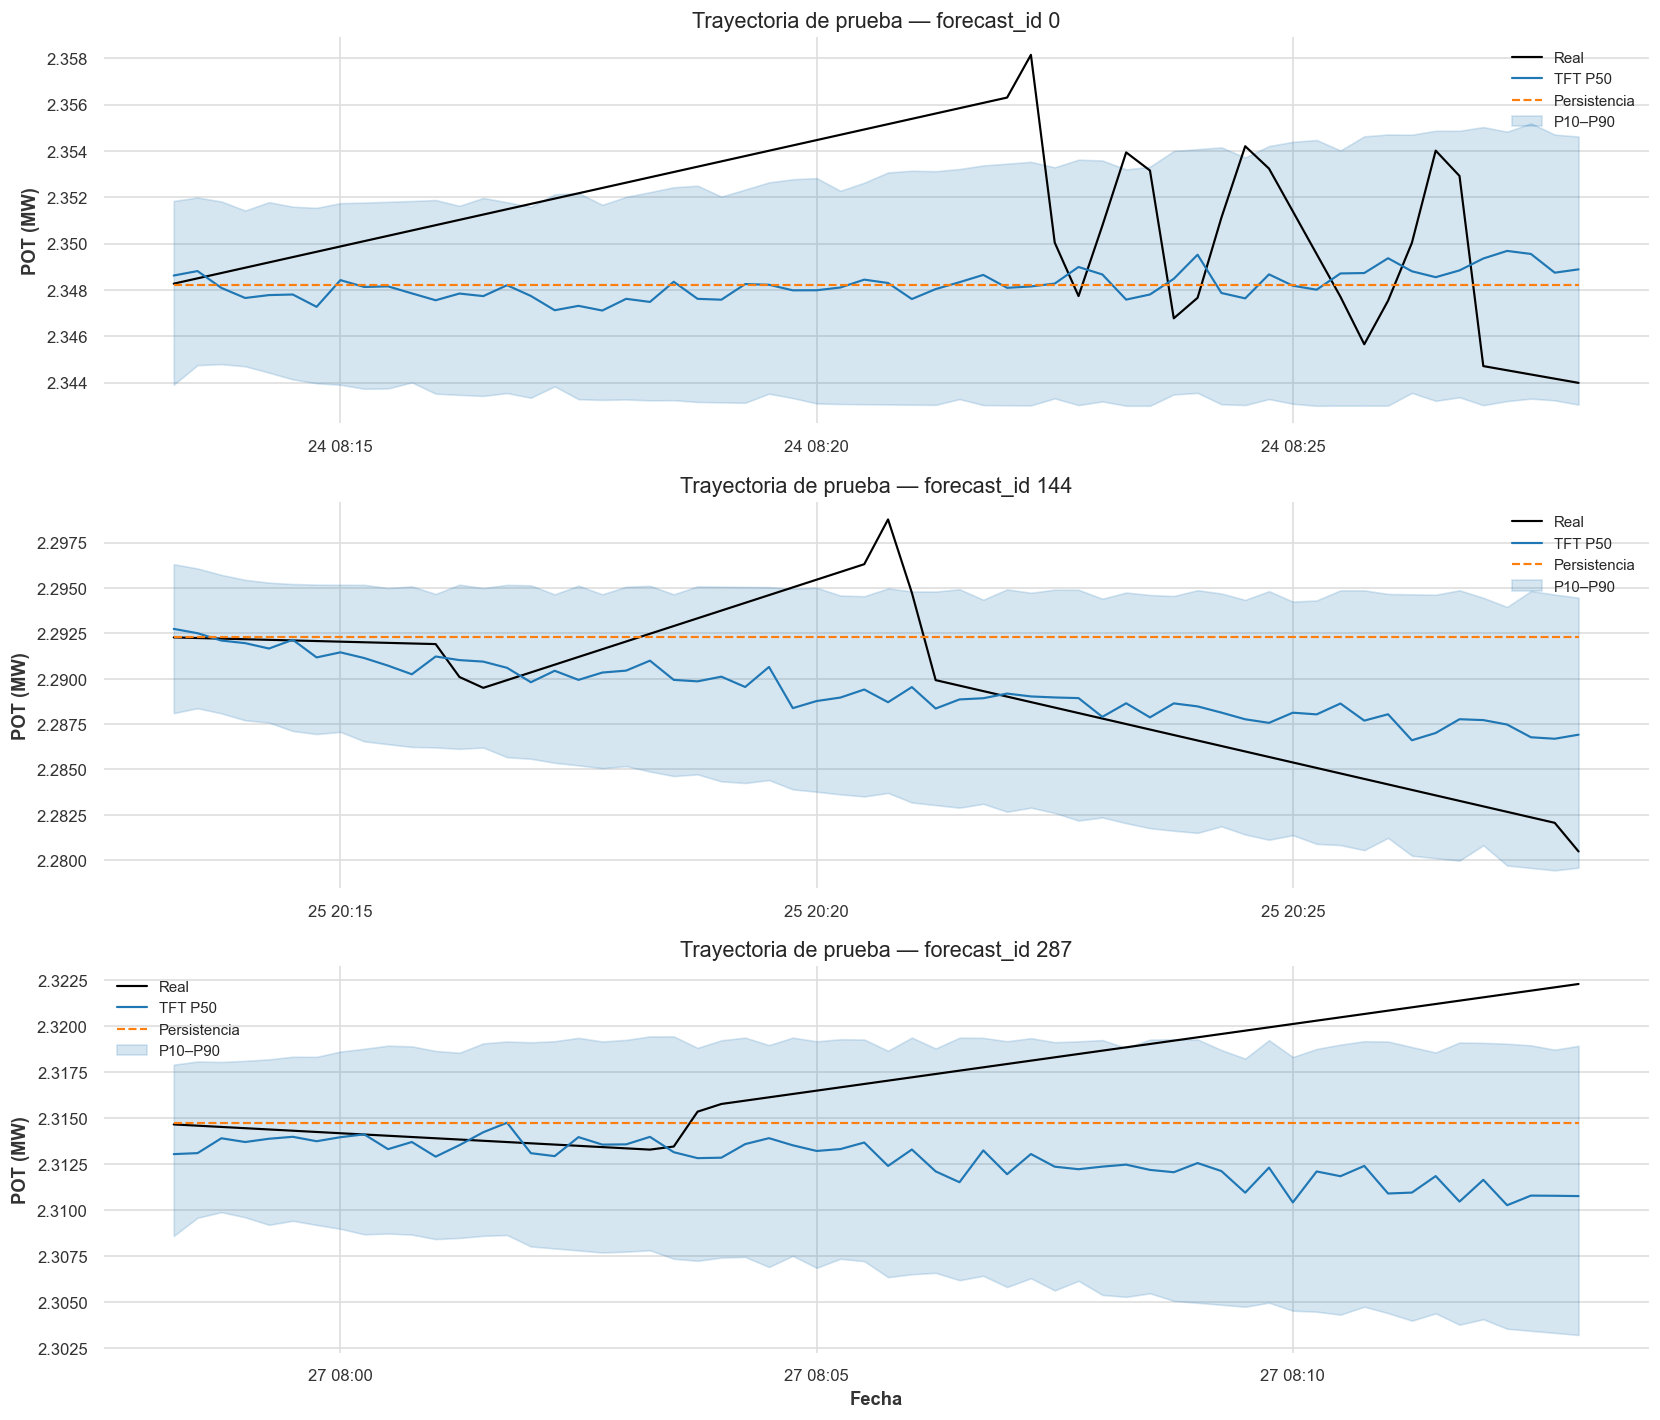

Figura guardada: resultados_tft_15min_final_prueba3\figuras\07_real_vs_predicho_prueba.png


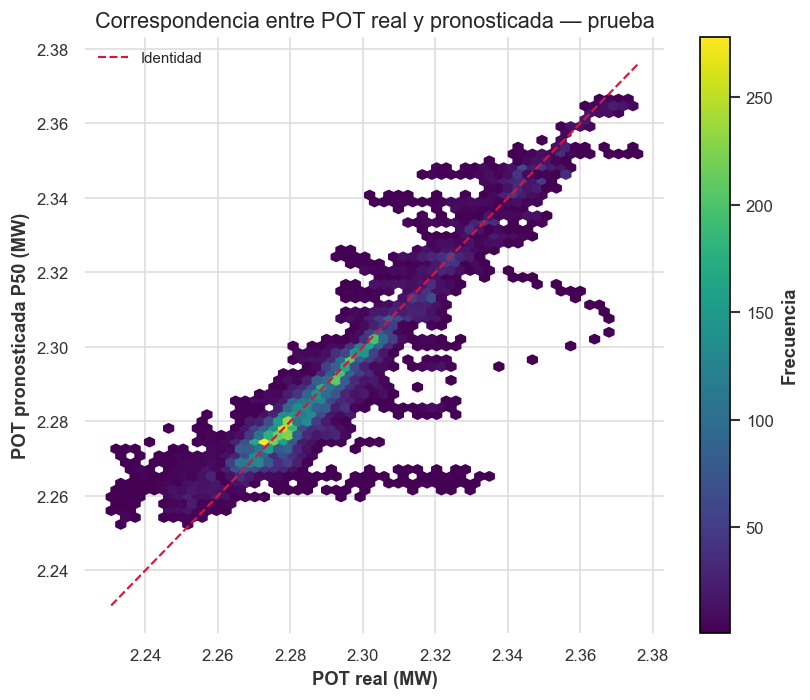

In [21]:
# ============================================================
# 21. FIGURAS DE RESULTADOS
# ============================================================

test_horizon = metrics_by_horizon[metrics_by_horizon["dataset"] == "TEST"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(test_horizon["lead_min"], test_horizon["MAE_TFT"], label="TFT P50")
axes[0].plot(
    test_horizon["lead_min"],
    test_horizon["MAE_PERSISTENCIA"],
    label="Persistencia",
)
axes[0].set_xlabel("Horizonte (minutos)")
axes[0].set_ylabel("MAE (MW)")
axes[0].set_title("MAE por horizonte — prueba")
axes[0].legend()

axes[1].plot(test_horizon["lead_min"], test_horizon["RMSE_TFT"], label="TFT P50")
axes[1].plot(
    test_horizon["lead_min"],
    test_horizon["RMSE_PERSISTENCIA"],
    label="Persistencia",
)
axes[1].set_xlabel("Horizonte (minutos)")
axes[1].set_ylabel("RMSE (MW)")
axes[1].set_title("RMSE por horizonte — prueba")
axes[1].legend()
save_figure("05_error_por_horizonte_prueba.png")
plt.show()

representative_ids = [0, eval_test["forecast_id"].nunique() // 2, eval_test["forecast_id"].nunique() - 1]
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
for axis, forecast_id in zip(axes, representative_ids):
    subset = eval_test[eval_test["forecast_id"] == forecast_id]
    axis.plot(subset.index, subset["y_true"], color="black", label="Real")
    axis.plot(subset.index, subset["y_pred_p50"], color="#1f77b4", label="TFT P50")
    axis.plot(subset.index, subset["y_persistencia"], color="#ff7f0e", linestyle="--", label="Persistencia")
    axis.fill_between(
        subset.index,
        subset["y_pred_p10"],
        subset["y_pred_p90"],
        color="#1f77b4",
        alpha=0.18,
        label="P10–P90",
    )
    axis.set_title(f"Trayectoria de prueba — forecast_id {forecast_id}")
    axis.set_ylabel("POT (MW)")
    axis.legend(loc="best")
axes[-1].set_xlabel("Fecha")
save_figure("06_trayectorias_representativas_prueba.png")
plt.show()

plt.figure(figsize=(7, 6))
plt.hexbin(
    eval_test["y_true"],
    eval_test["y_pred_p50"],
    gridsize=55,
    mincnt=1,
    cmap="viridis",
)
limits = [
    min(eval_test["y_true"].min(), eval_test["y_pred_p50"].min()),
    max(eval_test["y_true"].max(), eval_test["y_pred_p50"].max()),
]
plt.plot(limits, limits, color="crimson", linestyle="--", label="Identidad")
plt.xlabel("POT real (MW)")
plt.ylabel("POT pronosticada P50 (MW)")
plt.title("Correspondencia entre POT real y pronosticada — prueba")
plt.colorbar(label="Frecuencia")
plt.legend()
save_figure("07_real_vs_predicho_prueba.png")
plt.show()


## 10. Eventos de baja potencia e incertidumbre

La detección del umbral es un análisis complementario. Si existen pocos eventos, precisión, recall y F1 no deben utilizarse para afirmar capacidad de alarma. P10 se interpreta como señal conservadora de riesgo; P50 representa el pronóstico central.


In [22]:
# ============================================================
# 22. MÉTRICAS DE EVENTOS
# ============================================================

event_rows = []
for dataset_name, frame in [
    ("VALIDATION", eval_validation),
    ("TEST", eval_test),
]:
    event_rows.append({
        "dataset": dataset_name,
        "criterio": "P50_MENOR_UMBRAL",
        "umbral_mw": POWER_DANGER_THRESHOLD,
        **event_metrics(frame["y_true"], frame["y_pred_p50"]),
    })
    event_rows.append({
        "dataset": dataset_name,
        "criterio": "P10_MENOR_UMBRAL",
        "umbral_mw": POWER_DANGER_THRESHOLD,
        **event_metrics(frame["y_true"], frame["y_pred_p10"]),
    })

event_metrics_table = pd.DataFrame(event_rows)
display(event_metrics_table)
event_metrics_table.to_csv(TABLE_DIR / "metricas_eventos_tft.csv", index=False)

if event_metrics_table["REAL_EVENTS"].max() < 30:
    warnings.warn(
        "Existen menos de 30 puntos críticos en al menos el alcance evaluado; "
        "el análisis de alarmas debe considerarse exploratorio."
    )


,dataset,criterio,umbral_mw,TP,FP,FN,TN,PRECISION,RECALL,SPECIFICITY,F1,BALANCED_ACCURACY,REAL_EVENTS,PREDICTED_EVENTS
0,VALIDATION,P50_MENOR_UMBRAL,2.280000,3193,534,445,13108,0.856721,0.877680,0.960856,0.867074,0.919268,3638,3727
1,VALIDATION,P10_MENOR_UMBRAL,2.280000,3614,2685,24,10957,0.573742,0.993403,0.803181,0.727383,0.898292,3638,6299
2,TEST,P50_MENOR_UMBRAL,2.280000,5345,1083,560,10292,0.831518,0.905165,0.904791,0.866780,0.904978,5905,6428
3,TEST,P10_MENOR_UMBRAL,2.280000,5869,2887,36,8488,0.670283,0.993903,0.746198,0.800628,0.870051,5905,8756


,dataset,lead_step,lead_min,COVERAGE_P10_P90,MEAN_INTERVAL_WIDTH,PINBALL_P10,PINBALL_P50,PINBALL_P90,QUANTILE_CROSSING_RATE
0,VALIDATION,1,0.250000,0.940972,0.008965,0.000520,0.000801,0.000489,0.000000
1,VALIDATION,2,0.500000,0.916667,0.008344,0.000480,0.000857,0.000524,0.000000
2,VALIDATION,3,0.750000,0.899306,0.008262,0.000500,0.000943,0.000550,0.000000
3,VALIDATION,4,1.000000,0.885417,0.008471,0.000526,0.001029,0.000580,0.000000
4,VALIDATION,5,1.250000,0.892361,0.008726,0.000542,0.001105,0.000613,0.000000
...,...,...,...,...,...,...,...,...,...
115,TEST,56,14.000000,0.718750,0.017640,0.001605,0.003549,0.001987,0.000000
116,TEST,57,14.250000,0.722222,0.017845,0.001621,0.003593,0.002005,0.000000
117,TEST,58,14.500000,0.704861,0.017985,0.001628,0.003659,0.002029,0.000000
118,TEST,59,14.750000,0.718750,0.018088,0.001635,0.003691,0.002059,0.000000


Figura guardada: resultados_tft_15min_final_prueba3\figuras\08_incertidumbre_por_horizonte.png


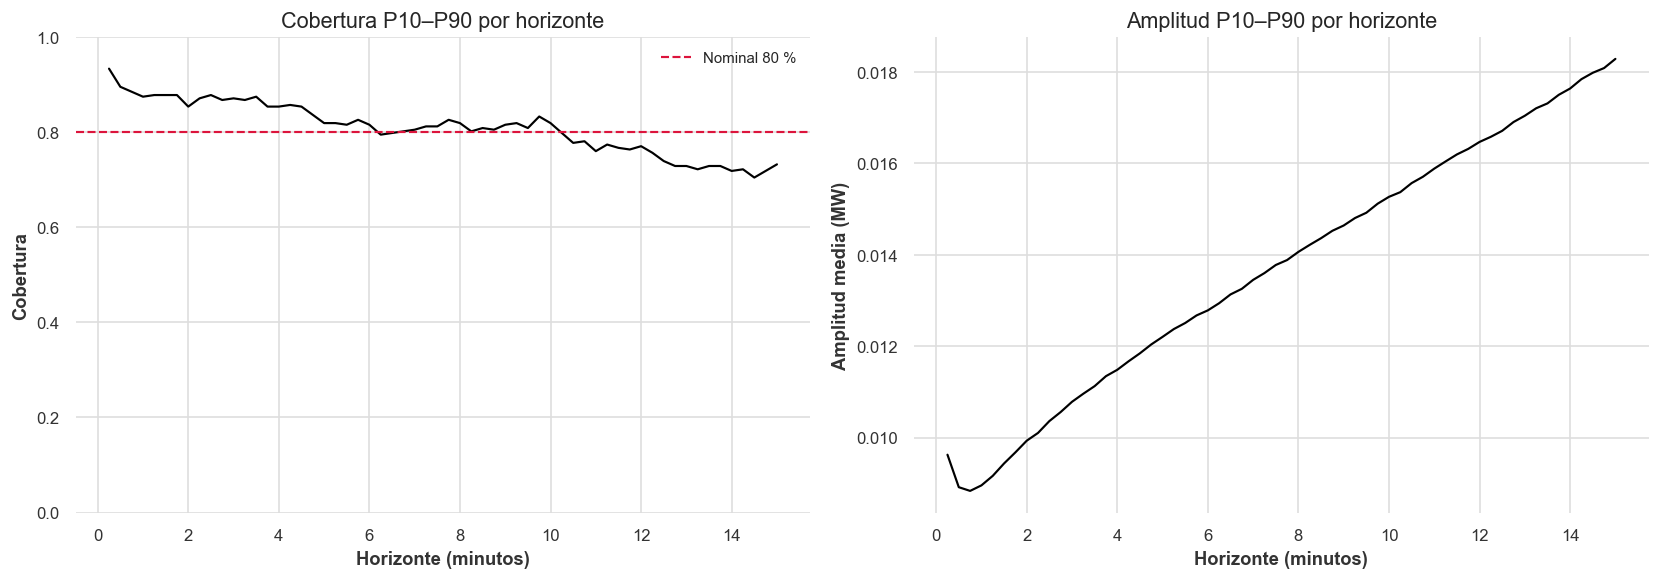

In [23]:
# ============================================================
# 23. INCERTIDUMBRE POR HORIZONTE
# ============================================================

uncertainty_rows = []
for dataset_name, frame in [
    ("VALIDATION", eval_validation),
    ("TEST", eval_test),
]:
    for lead_step, subset in frame.groupby("lead_step"):
        uncertainty_rows.append({
            "dataset": dataset_name,
            "lead_step": int(lead_step),
            "lead_min": float(subset["lead_min"].iloc[0]),
            **probabilistic_metrics(subset),
        })

uncertainty_by_horizon = pd.DataFrame(uncertainty_rows)
display(uncertainty_by_horizon)
uncertainty_by_horizon.to_csv(
    TABLE_DIR / "incertidumbre_por_horizonte_tft.csv",
    index=False,
)

test_uncertainty = uncertainty_by_horizon[
    uncertainty_by_horizon["dataset"] == "TEST"
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(test_uncertainty["lead_min"], test_uncertainty["COVERAGE_P10_P90"])
axes[0].axhline(0.80, color="crimson", linestyle="--", label="Nominal 80 %")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Horizonte (minutos)")
axes[0].set_ylabel("Cobertura")
axes[0].set_title("Cobertura P10–P90 por horizonte")
axes[0].legend()

axes[1].plot(test_uncertainty["lead_min"], test_uncertainty["MEAN_INTERVAL_WIDTH"])
axes[1].set_xlabel("Horizonte (minutos)")
axes[1].set_ylabel("Amplitud media (MW)")
axes[1].set_title("Amplitud P10–P90 por horizonte")
save_figure("08_incertidumbre_por_horizonte.png")
plt.show()


## 11. Robustez estadística

Para complementar las métricas puntuales se aplica un bootstrap pareado sobre todas las trayectorias de prueba. Cada trayectoria conserva conjuntamente sus `OUTPUT_CHUNK_LENGTH` errores, reduciendo el optimismo que produciría remuestrear observaciones individuales como si fueran independientes.


In [24]:
# ============================================================
# 24. BOOTSTRAP PAREADO POR TRAYECTORIA
# ============================================================

def paired_path_bootstrap(frame, repetitions=BOOTSTRAP_REPETITIONS, seed=SEED):
    path_loss = (
        frame.assign(
            abs_error_tft=lambda data: np.abs(data["y_true"] - data["y_pred_p50"]),
            abs_error_persistence=lambda data: np.abs(data["y_true"] - data["y_persistencia"]),
        )
        .groupby("forecast_id")[["abs_error_tft", "abs_error_persistence"]]
        .mean()
    )
    differences = (
        path_loss["abs_error_persistence"] - path_loss["abs_error_tft"]
    ).to_numpy()

    rng = np.random.default_rng(seed)
    bootstrap_means = np.empty(repetitions)
    n_paths = len(differences)

    for repetition in range(repetitions):
        sample_indices = rng.integers(0, n_paths, size=n_paths)
        bootstrap_means[repetition] = differences[sample_indices].mean()

    estimate = differences.mean()
    ci_low, ci_high = np.quantile(bootstrap_means, [0.025, 0.975])
    probability_improvement = np.mean(bootstrap_means > 0)

    return {
        "trayectorias": n_paths,
        "pasos_por_trayectoria": OUTPUT_CHUNK_LENGTH,
        "horizonte_minutos": HORIZON_MINUTES,
        "bootstrap_unit": f"forecast_path_{OUTPUT_CHUNK_LENGTH}_steps_{HORIZON_TAG}",
        "diferencia_mae_persistencia_menos_tft": float(estimate),
        "IC95_inferior": float(ci_low),
        "IC95_superior": float(ci_high),
        "probabilidad_mejora_tft": float(probability_improvement),
    }


bootstrap_result = paired_path_bootstrap(eval_test)
bootstrap_table = pd.DataFrame([bootstrap_result])
display(bootstrap_table)
bootstrap_table.to_csv(TABLE_DIR / "bootstrap_comparacion_tft_persistencia.csv", index=False)


,trayectorias,pasos_por_trayectoria,horizonte_minutos,bootstrap_unit,diferencia_mae_persistencia_menos_tft,IC95_inferior,IC95_superior,probabilidad_mejora_tft
0,288,60,15.000000,forecast_path_60_steps_15min,0.000350,0.000018,0.000669,0.980000


## 12. Explicabilidad interna del TFT

La selección de variables y la atención permiten describir qué información utiliza el modelo. Estos valores son **relevancia predictiva interna**, no efectos causales ni recomendaciones de manipulación del proceso. La celda está protegida para que una incompatibilidad puntual del explainer no invalide el experimento principal.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

Importancias internas del TFT:


{'encoder_importance':    T_pastcov  AA_pastcov  F80_pastcov  add_relative_index_futcov  AD_pastcov  POT_target
 0   2.900000    5.500000     7.500000                  18.100000   21.200000   44.800000,
 'decoder_importance':    add_relative_index_futcov
 0                 100.000000,
 'static_covariates_importance': Empty DataFrame
 Columns: []
 Index: []}

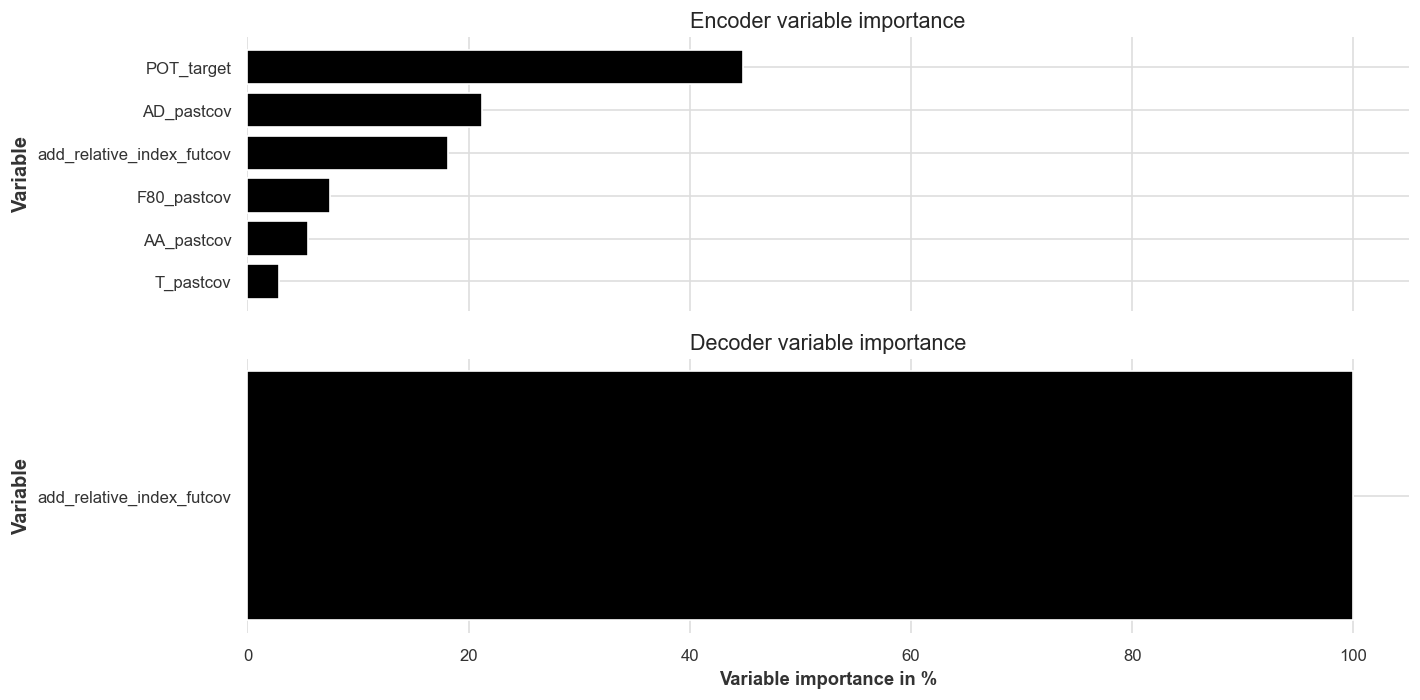

<Figure size 1440x600 with 0 Axes>

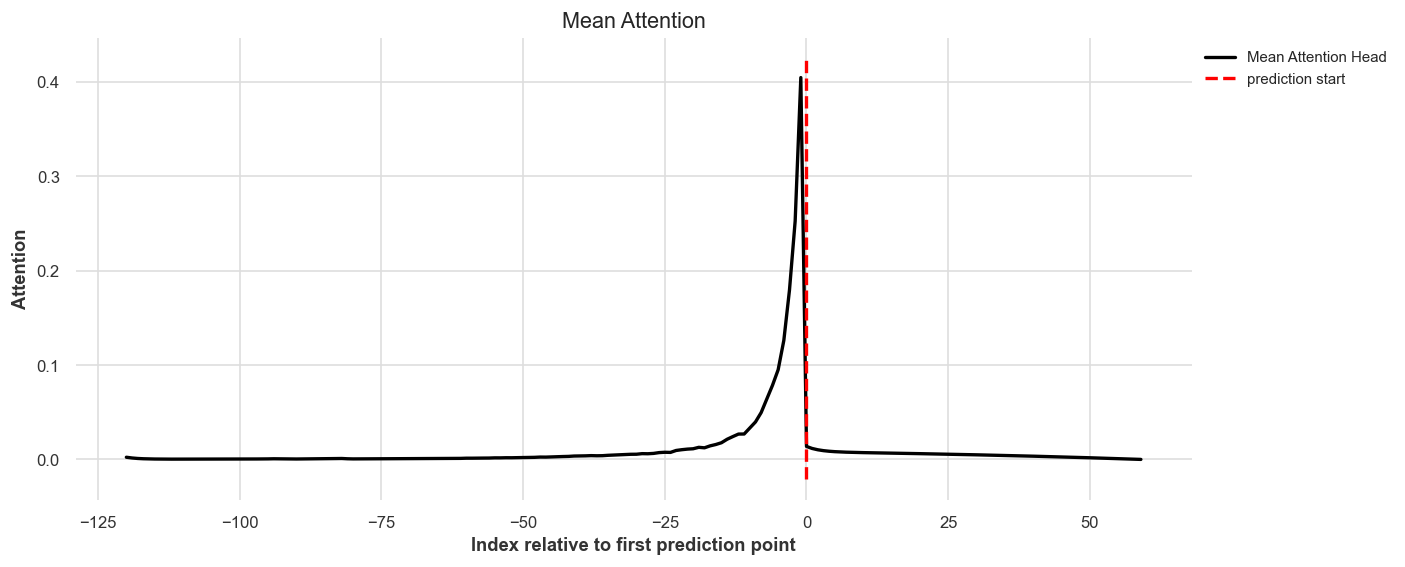

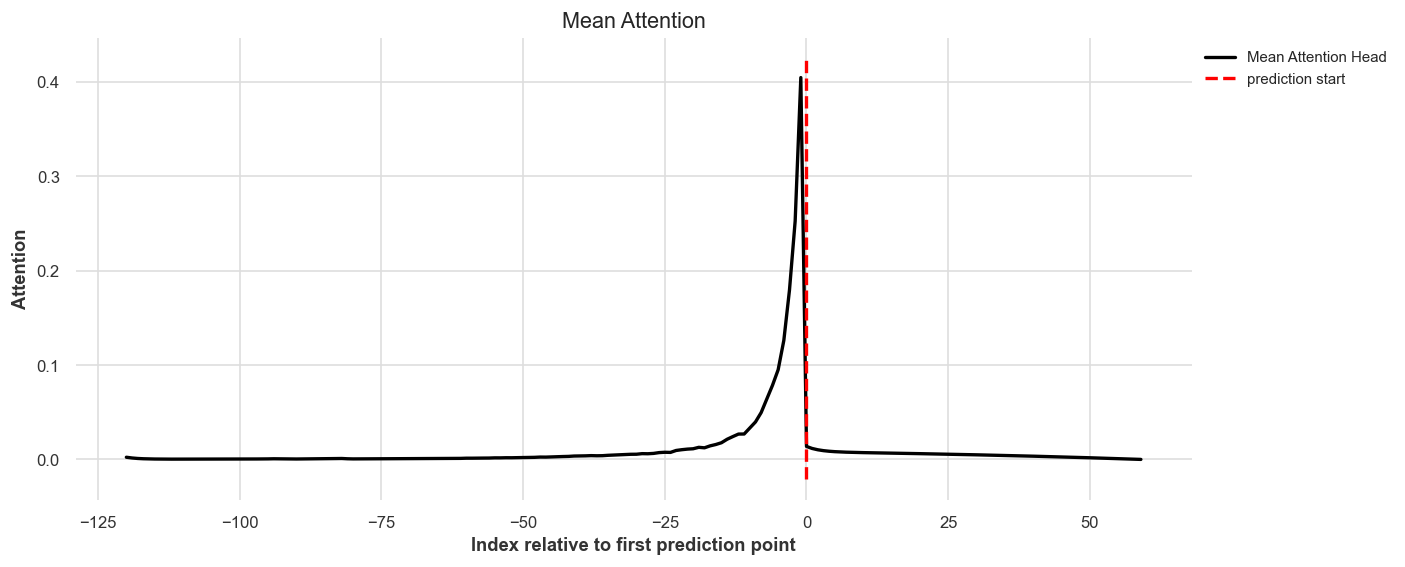

TFTExplainer ejecutado correctamente; importancias y figuras procesadas.


In [25]:
# ============================================================
# 25. TFT EXPLAINER (COMPLEMENTARIO)
# ============================================================

RUN_TFT_EXPLAINABILITY = True
explainability_status = {
    "executed": False,
    "error": None,
    "variable_selection_figures": 0,
    "attention_figures": 0,
}

def guardar_figuras_explicador(plot_result, filename_prefix):
    """Guarda figuras devueltas por Darts o la figura activa si retorna None."""
    if isinstance(plot_result, (list, tuple)):
        candidates = list(plot_result)
    elif plot_result is None:
        current = plt.gcf()
        candidates = [current] if current is not None and current.axes else []
    else:
        candidates = [plot_result]

    saved = 0
    for candidate in candidates:
        figure = getattr(candidate, "figure", candidate)
        if figure is None or not hasattr(figure, "savefig"):
            continue
        figure.savefig(
            FIGURE_DIR / f"{filename_prefix}_{saved}.png",
            dpi=300,
            bbox_inches="tight",
        )
        display(figure)
        saved += 1
    return saved

if RUN_TFT_EXPLAINABILITY:
    try:
        from darts.explainability.tft_explainer import TFTExplainer

        foreground_y = series_y_scaled[
            test_start_idx - INPUT_CHUNK_LENGTH:test_start_idx
        ]
        foreground_past = series_past_scaled[
            test_start_idx - INPUT_CHUNK_LENGTH:test_start_idx
        ]

        explainer = TFTExplainer(
            best_model,
            background_series=foreground_y,
            background_past_covariates=foreground_past,
        )
        explanation = explainer.explain(
            foreground_series=foreground_y,
            foreground_past_covariates=foreground_past,
        )

        feature_importances = explanation.get_feature_importances()
        print("Importancias internas del TFT:")
        display(feature_importances)

        if isinstance(feature_importances, dict):
            for key, value in feature_importances.items():
                if isinstance(value, pd.DataFrame):
                    value.to_csv(TABLE_DIR / f"tft_importancia_{key}.csv")

        variable_plot = explainer.plot_variable_selection(
            explanation,
            fig_size=(12, 6),
        )
        explainability_status["variable_selection_figures"] = guardar_figuras_explicador(
            variable_plot,
            "09_tft_seleccion_variables",
        )

        attention_plot = explainer.plot_attention(
            explanation,
            plot_type="time",
            show_index_as="relative",
        )
        explainability_status["attention_figures"] = guardar_figuras_explicador(
            attention_plot,
            "10_tft_atencion",
        )

        explainability_status["executed"] = True
        print("TFTExplainer ejecutado correctamente; importancias y figuras procesadas.")
    except Exception as explainability_error:
        explainability_status["error"] = str(explainability_error)
        warnings.warn(
            "No fue posible completar TFTExplainer. El entrenamiento y las métricas "
            f"siguen siendo válidos. Detalle: {explainability_error}"
        )

save_json(explainability_status, TABLE_DIR / "estado_explicabilidad_tft.json")


## 13. Consolidación de artefactos y resumen final

La última celda verifica que todos los resultados esenciales existan y crea un resumen legible para trasladar posteriormente a la tesis. **No modificar manualmente los CSV exportados**; se consideran evidencia reproducible de la corrida.


In [26]:
# ============================================================
# 26. RESUMEN FINAL Y MANIFIESTO
# ============================================================

environment = {
    "python": sys.version,
    "platform": platform.platform(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "darts": darts.__version__,
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "lightning_import": lightning_package,
    "dataset_sha256": dataset_sha256,
}
save_json(environment, ARTIFACT_DIR / "entorno_ejecucion.json")

test_tft = global_metrics.query("dataset == 'TEST' and modelo == 'TFT_P50'").iloc[0]
test_persistence = global_metrics.query("dataset == 'TEST' and modelo == 'PERSISTENCIA'").iloc[0]
test_probability = probability_metrics_table.query("dataset == 'TEST'").iloc[0]
final_horizon_test = final_horizon.query("dataset == 'TEST'").iloc[0]

summary = {
    "dataset": {
        "raw_rows": len(df_raw),
        "model_rows": len(df_15s),
        "date_min": df_15s.index.min(),
        "date_max": df_15s.index.max(),
        "sha256": dataset_sha256,
    },
    "training": {
        "seconds": training_seconds,
        "configuration": model_configuration,
    },
    "evaluation": {
        "seconds": evaluation_seconds,
        "horizon_steps": OUTPUT_CHUNK_LENGTH,
        "horizon_minutes": HORIZON_MINUTES,
        "rolling_stride_steps": ROLLING_STRIDE,
        "validation_forecast_paths": int(eval_validation["forecast_id"].nunique()),
        "test_forecast_paths": int(eval_test["forecast_id"].nunique()),
        "test_tft": test_tft.to_dict(),
        "test_persistence": test_persistence.to_dict(),
        "test_probability": test_probability.to_dict(),
        "test_final_horizon": final_horizon_test.to_dict(),
        "bootstrap": bootstrap_result,
    },
    "explainability": explainability_status,
}
save_json(summary, ARTIFACT_DIR / "resumen_resultados_tft.json")

summary_lines = [
    "RESUMEN EJECUTIVO — TFT POTENCIA MOLINO 1D",
    "=" * 52,
    f"Periodo: {df_15s.index.min()} -> {df_15s.index.max()}",
    f"Filas finales a 15 s: {len(df_15s):,}",
    f"Horizonte: {OUTPUT_CHUNK_LENGTH} pasos = {HORIZON_MINUTES:g} min",
    f"Trayectorias de prueba: {eval_test['forecast_id'].nunique()}",
    f"MAE TFT prueba: {test_tft['MAE']:.8f} MW",
    f"RMSE TFT prueba: {test_tft['RMSE']:.8f} MW",
    f"MAPE TFT prueba: {test_tft['MAPE']:.6f} %",
    f"R² TFT prueba: {test_tft['R2']:.8f}",
    f"MAE persistencia prueba: {test_persistence['MAE']:.8f} MW",
    f"RMSE persistencia prueba: {test_persistence['RMSE']:.8f} MW",
    f"Cobertura P10-P90 prueba: {test_probability['COVERAGE_P10_P90']:.4%}",
    f"Amplitud P10-P90 prueba: {test_probability['MEAN_INTERVAL_WIDTH']:.8f} MW",
    f"RMSE TFT al horizonte final: {final_horizon_test['RMSE_TFT']:.8f} MW",
    f"R² TFT al horizonte final: {final_horizon_test['R2_TFT']:.8f}",
    f"Mejora MAE final vs persistencia: {final_horizon_test['MEJORA_MAE_PCT']:.4f} %",
]

summary_path = ARTIFACT_DIR / "resumen_ejecutivo_tft.txt"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
print(summary_path.read_text(encoding="utf-8"))

required_artifacts = [
    TABLE_DIR / "metricas_globales_tft.csv",
    TABLE_DIR / "metricas_por_horizonte_tft.csv",
    TABLE_DIR / "metricas_horizonte_final_tft.csv",
    TABLE_DIR / "metricas_probabilisticas_tft.csv",
    TABLE_DIR / "predicciones_prueba_tft.csv",
    MODEL_DIR / "tft_modelo_final.pt",
    ARTIFACT_DIR / "resumen_resultados_tft.json",
    ARTIFACT_DIR / "resumen_ejecutivo_tft.txt",
]

missing_artifacts = [str(path) for path in required_artifacts if not path.exists()]
if missing_artifacts:
    raise FileNotFoundError(f"Faltan artefactos obligatorios: {missing_artifacts}")

manifest = pd.DataFrame({
    "archivo": [str(path) for path in sorted(ARTIFACT_DIR.rglob("*")) if path.is_file()]
})
manifest.to_csv(ARTIFACT_DIR / "manifiesto_archivos.csv", index=False)

print(f"\nPROCESO TFT FINALIZADO CORRECTAMENTE PARA {HORIZON_MINUTES:g} MIN")
print("Carpeta de resultados:", ARTIFACT_DIR.resolve())


RESUMEN EJECUTIVO — TFT POTENCIA MOLINO 1D
Periodo: 2026-08-01 14:45:00 -> 2026-08-27 08:13:00
Filas finales a 15 s: 148,193
Horizonte: 60 pasos = 15 min
Trayectorias de prueba: 288
MAE TFT prueba: 0.00462843 MW
RMSE TFT prueba: 0.00728147 MW
MAPE TFT prueba: 0.201784 %
R² TFT prueba: 0.90256104
MAE persistencia prueba: 0.00497841 MW
RMSE persistencia prueba: 0.00786209 MW
Cobertura P10-P90 prueba: 80.9664%
Amplitud P10-P90 prueba: 0.01369985 MW
RMSE TFT al horizonte final: 0.01106049 MW
R² TFT al horizonte final: 0.77427139
Mejora MAE final vs persistencia: 10.2557 %

PROCESO TFT FINALIZADO CORRECTAMENTE PARA 15 MIN
Carpeta de resultados: C:\Users\jgomeze\Documents\woody\Py\resultados_tft_15min_final_prueba3


## 14. Criterios para interpretar la corrida

Antes de trasladar los resultados a la tesis, comprobar:

1. Que los ocho controles del archivo crudo sean `True`.
2. Que existan exactamente 148.193 observaciones completas a 15 segundos.
3. Que validación y prueba coincidan con `resumen_origenes_tft.csv`.
4. Que cada trayectoria contenga `OUTPUT_CHUNK_LENGTH` pasos.
5. Que el error de persistencia en el primer paso sea distinto de cero.
6. Que la comparación principal se realice sobre prueba.
7. Que cobertura y amplitud se interpreten conjuntamente.
8. Que atención y selección de variables no se presenten como causalidad.
9. Que las conclusiones sobre eventos críticos sean exploratorias si su frecuencia es baja.

### Referencias metodológicas principales

- Lim, B., Arik, S. O., Loeff, N., & Pfister, T. (2021). *Temporal Fusion Transformers for interpretable multi-horizon time series forecasting*. International Journal of Forecasting, 37(4), 1748–1764. https://doi.org/10.1016/j.ijforecast.2021.03.012
- Darts Development Team. (2024). *Darts 0.31.0 documentation*. https://unit8co.github.io/darts/
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.
